# Notebook 05 — Modelo de precipitación Bernoulli-Gamma

La precipitación se separa en dos procesos:

- **Ocurrencia** — si llueve o no en un día dado, modelada con un **Logit** sobre estacionalidad + temperatura + lags.
- **Intensidad** — cuánto llueve cuando sí llueve, modelada con una **GLM Gamma** (link logarítmico) con los mismos regresores.

Predicción esperada del modelo: $\mathbb{E}[P_t] = P(\text{llueve}_t) \cdot \mathbb{E}[P_t \mid \text{llueve}_t]$.

El umbral para considerar un día como "lluvioso" se fija en **5 mm** (corte estándar de OMM para lluvia moderada). Se hace un check de sensibilidad al final.

In [8]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ValueWarning)

OUT_DIR = Path('../data/processed')

In [9]:
df = pd.read_excel('../data/processed/Modelo_Completo.xlsx')

df['date'] = pd.to_datetime(df['date'])

cols = ['precip']
df_Casanare = df[df['department'] == 'Casanare'].set_index('date')[cols].copy()
df_Tolima   = df[df['department'] == 'Tolima'  ].set_index('date')[cols].copy()

print(f"Casanare: {df_Casanare.shape}  |  Tolima: {df_Tolima.shape}")

Casanare: (5844, 1)  |  Tolima: (5844, 1)


## Ajuste y validación del modelo Bernoulli-Gamma

In [10]:
def _stochastic_recursive_forecast(modelo_logit, modelo_gamma, test_df, vars_list,
                                   threshold, n_sims=200, seed=42, clip_intensity=200):
    """
    Pronóstico recursivo OOS sin contaminación de lags reales.

    En cada paso t del set de test:
      - Construye el regresor usando los lags PRONOSTICADOS (no observados).
      - Calcula p_t (Logit) y mu_t (Gamma).
      - Simula estocásticamente: rain_t ~ Bernoulli(p_t); si rain_t=1 entonces
        precip_t ~ Gamma(media=mu_t, scale=phi del Gamma); si no, precip_t=0.
      - El precip_t simulado se usa como lag para t+1.

    Se repite n_sims trayectorias y se promedia para obtener E[precip_t | info_train].
    El promedio sobre simulaciones evita el sesgo positivo de inyectar
    determinísticamente p_t * E[intensidad_t] como lag (que se autoamplifica).

    Retorna
    -------
    pred_mean : pd.Series con la predicción esperada (promedio sobre trayectorias).
    pred_paths: ndarray (n_sims, n_test) con todas las trayectorias.
    """
    rng = np.random.default_rng(seed)
    n_test = len(test_df)
    feat_cols = ['sin_year', 'cos_year']  # determinísticos (estacionalidad)
    seasonal = test_df[feat_cols].to_numpy()  # (n_test, 2)

    # Estado inicial de los lags: tomar los dos últimos valores OBSERVADOS
    # justo antes del test (esto es información disponible en t=split-1, no fuga).
    lag1_init = float(test_df['lag1_precip'].iloc[0])
    lag2_init = float(test_df['lag2_precip'].iloc[0])

    # Coeficientes del Logit y del Gamma (orden: const, sin, cos, lag1, lag2)
    b_logit = modelo_logit.params.values
    b_gamma = modelo_gamma.params.values
    phi     = float(modelo_gamma.scale)  # parámetro de dispersión Gamma (Var = phi*mu^2)

    pred_paths = np.zeros((n_sims, n_test))

    for s in range(n_sims):
        lag1, lag2 = lag1_init, lag2_init
        for t in range(n_test):
            x = np.array([1.0, seasonal[t, 0], seasonal[t, 1], lag1, lag2])
            # Logit
            eta_l = x @ b_logit
            p_t = 1.0 / (1.0 + np.exp(-eta_l))
            # Gamma
            mu_t = np.exp(x @ b_gamma)
            mu_t = min(mu_t, clip_intensity)
            # Sample
            rain = rng.random() < p_t
            if rain:
                # Gamma con media mu y varianza phi*mu^2  →  shape k = 1/phi, scale θ = mu*phi
                k = 1.0 / phi if phi > 0 else 1.0
                theta = mu_t * phi if phi > 0 else mu_t
                precip_t = rng.gamma(shape=k, scale=theta)
                precip_t = min(precip_t, clip_intensity)
            else:
                precip_t = 0.0
            pred_paths[s, t] = precip_t
            # Avanzar lags
            lag2 = lag1
            lag1 = precip_t

    pred_mean = pred_paths.mean(axis=0)
    return pd.Series(pred_mean, index=test_df.index, name='BG'), pred_paths


def ajustar_bernoulli_gamma(df_dpto, nombre_dpto, frecuencia='diaria', threshold=5,
                            n_sims_oos=200, seed=42, verbose_coefs=True):
    """
    Ajusta y valida el modelo Bernoulli-Gamma para precipitación.

    Cambios respecto a la versión previa
    ------------------------------------
    1) La predicción OOS YA NO usa los lags reales del test (eso era data leakage).
       Se hace un pronóstico recursivo estocástico: los lags se alimentan con la
       precipitación SIMULADA del paso anterior, promediando n_sims_oos trayectorias.
    2) La simulación estocástica (Bernoulli × Gamma) rompe el sesgo positivo del
       feedback determinístico p_t * E[intensidad_t] como lag (que se autoamplifica
       porque ambos coeficientes sobre los lags suelen ser positivos).
    3) Se imprimen los coeficientes del Logit y del Gamma con error estándar y p-valor.

    Parámetros
    ----------
    df_dpto       : DataFrame con índice datetime y columna precip.
    nombre_dpto   : str — etiqueta para títulos/mensajes.
    frecuencia    : 'diaria' | 'mensual' | 'trimestral' | 'semestral' | 'anual'.
    threshold     : umbral en mm para clasificar día como "lluvioso" (default 5 mm).
    n_sims_oos    : número de trayectorias Monte Carlo para el pronóstico OOS recursivo.
    seed          : semilla para reproducibilidad.
    verbose_coefs : si True, imprime tabla de coeficientes de Logit y Gamma.
    """
    FRECUENCIAS = {'diaria': 'D', 'mensual': 'ME', 'trimestral': 'QE',
                   'semestral': '6ME', 'anual': 'YE'}
    frec_code = FRECUENCIAS.get(frecuencia.lower())
    if frec_code is None:
        raise ValueError(f"frecuencia '{frecuencia}' no válida.")

    print(f"\n{'='*70}")
    print(f"  BERNOULLI-GAMMA | {nombre_dpto.upper()} | umbral={threshold} mm | OOS {frecuencia}")
    print(f"{'='*70}")

    df = df_dpto.copy()

    # ── Paso 1: Features (estacionalidad cíclica + lags) ─────────────────────
    d = df.index.dayofyear
    df['sin_year']    = np.sin(2 * np.pi * d / 365)
    df['cos_year']    = np.cos(2 * np.pi * d / 365)
    df['lag1_precip'] = df['precip'].shift(1)
    df['lag2_precip'] = df['precip'].shift(2)
    df['rain_flag']   = (df['precip'] > threshold).astype(int)
    df = df.dropna()

    # ── Paso 2: Train / test split (80/20) ───────────────────────────────────
    split_idx = int(len(df) * 0.80)
    train, test = df.iloc[:split_idx], df.iloc[split_idx:]

    VARS = ['sin_year', 'cos_year', 'lag1_precip', 'lag2_precip']
    X_train = sm.add_constant(train[VARS])

    # ── Paso 3: Logit (ocurrencia) ───────────────────────────────────────────
    modelo_logit = sm.Logit(train['rain_flag'], X_train).fit(method='bfgs', disp=0)
    print(f"\n[1] Logit (ocurrencia): pseudo-R² = {modelo_logit.prsquared:.4f}")

    # ── Paso 4: Gamma (intensidad, solo días lluviosos) ──────────────────────
    train_lluvia = train[train['rain_flag'] == 1]
    X_gamma = sm.add_constant(train_lluvia[VARS])
    modelo_gamma = sm.GLM(
        train_lluvia['precip'], X_gamma,
        family=sm.families.Gamma(link=sm.families.links.Log())
    ).fit()
    print(f"[2] Gamma (intensidad): scale (φ) = {modelo_gamma.scale:.4f}")

    # ── Paso 4b: Imprimir coeficientes ───────────────────────────────────────
    if verbose_coefs:
        def _tabla_coefs(modelo, titulo):
            tabla = pd.DataFrame({
                'coef':    modelo.params,
                'std_err': modelo.bse,
                'z':       modelo.tvalues,
                'p>|z|':   modelo.pvalues,
            }).round(4)
            print(f"\n   [{titulo}] coeficientes:")
            print(tabla.to_string())
        _tabla_coefs(modelo_logit, 'Logit')
        _tabla_coefs(modelo_gamma, 'Gamma')

    # ── Paso 5: Predicción in-sample (train) ─────────────────────────────────
    p_train    = modelo_logit.predict(X_train)
    int_train  = np.clip(modelo_gamma.predict(X_train), 0, 200)
    pred_train = p_train * int_train

    residuales_train = train['precip'] - pred_train

    # ── Paso 6: Diagnóstico de residuales ────────────────────────────────────
    resid_agg = residuales_train.resample(frec_code).mean().dropna()

    jb_stat, jb_p = stats.jarque_bera(resid_agg)
    print(f"\n[3] Diagnóstico de residuales agregados ({frecuencia}):")
    print(f"   Jarque-Bera : stat={jb_stat:.2f},  p={jb_p:.3e}"
          f" → {'rechaza normalidad' if jb_p < 0.05 else 'no rechaza normalidad'}")

    mu_n, sig_n          = stats.norm.fit(resid_agg)
    df_t, loc_t, scale_t = stats.t.fit(resid_agg)
    ll_n = stats.norm.logpdf(resid_agg, mu_n, sig_n).sum()
    ll_t = stats.t.logpdf(resid_agg, df_t, loc_t, scale_t).sum()
    aic_n = 2*2 - 2*ll_n;  aic_t = 2*3 - 2*ll_t
    mejor = 't' if aic_t < aic_n else 'normal'

    print(f"   Normal    : μ={mu_n:.4f},  σ={sig_n:.4f}      AIC={aic_n:.1f}")
    print(f"   t-Student : df={df_t:.2f}, loc={loc_t:.4f}, scale={scale_t:.4f}  AIC={aic_t:.1f}")
    print(f"   → Selección AIC: {'t-Student' if mejor == 't' else 'Normal'}")

    # ── Paso 7: Predicción OOS — RECURSIVA y ESTOCÁSTICA ─────────────────────
    # FIX: no usar test[VARS] directamente porque lag1/lag2 vienen del test real
    # (contaminación). En su lugar, simular trayectorias alimentando lags propios.
    pred_test_series, pred_paths = _stochastic_recursive_forecast(
        modelo_logit, modelo_gamma, test, VARS,
        threshold=threshold, n_sims=n_sims_oos, seed=seed, clip_intensity=200
    )

    df_oos = pd.DataFrame({
        'Real': test['precip'],
        'BG':   pred_test_series,
    }, index=test.index).resample(frec_code).sum()

    rmse = np.sqrt(mean_squared_error(df_oos['Real'], df_oos['BG']))
    mae  = mean_absolute_error(df_oos['Real'], df_oos['BG'])
    print(f"\n[4] Validación OOS recursiva ({frecuencia}, n_sims={n_sims_oos}):"
          f"  RMSE = {rmse:.3f} mm,  MAE = {mae:.3f} mm")

    # Diagnóstico de sesgo: comparar media simulada vs media observada en el test
    media_real = float(test['precip'].mean())
    media_sim  = float(pred_test_series.mean())
    print(f"   Media diaria observada (test) : {media_real:.3f} mm")
    print(f"   Media diaria simulada  (test) : {media_sim:.3f} mm"
          f"  → sesgo = {media_sim - media_real:+.3f} mm")

    # ── Paso 8: Visualización ────────────────────────────────────────────────
    _graficar_diagnostico(resid_agg, mu_n, sig_n, df_t, loc_t, scale_t,
                          frecuencia, nombre_dpto)
    _graficar_oos(df_oos, nombre_dpto, frecuencia)

    # ── Paso 9: Parámetros para simulación Monte Carlo ───────────────────────
    parametros_mc = {
        'threshold_lluvia': threshold,
        'logit_coefs':      modelo_logit.params.to_dict(),
        'gamma_coefs':      modelo_gamma.params.to_dict(),
        'gamma_scale':      float(modelo_gamma.scale),
        'residuales_normal': {'mu': float(mu_n), 'sigma': float(sig_n)},
        'residuales_t':      {'df': float(df_t), 'loc': float(loc_t), 'scale': float(scale_t)},
        'residuales_mejor':  ('t' if mejor == 't' else 'normal'),
        'rmse_oos': float(rmse),
        'mae_oos':  float(mae),
        'jb_p':     float(jb_p),
        'oos_recursivo': True,
        'oos_n_sims':    int(n_sims_oos),
    }

    return {
        'tabla_resultados': pd.DataFrame({'Modelo': ['Bernoulli-Gamma'],
                                           'RMSE': [rmse], 'MAE': [mae]}),
        'parametros_mc':    parametros_mc,
        'modelo_logit':     modelo_logit,
        'modelo_gamma':     modelo_gamma,
        'pred_oos_paths':   pred_paths,
    }


def _graficar_diagnostico(resid, mu, sig, df_t, loc_t, scale_t, frecuencia, nombre):
    fig = plt.figure(figsize=(16, 9))
    fig.suptitle(f'Diagnóstico de residuales BG ({frecuencia}) — {nombre}',
                 fontsize=13, fontweight='bold')

    ax1 = plt.subplot2grid((2, 2), (0, 0), rowspan=2)
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    ax3 = plt.subplot2grid((2, 2), (1, 1))

    x = np.linspace(resid.min(), resid.max(), 400)
    ax1.hist(resid, bins=40, density=True, alpha=0.45, color='slategrey', label='Residuales')
    ax1.plot(x, stats.norm.pdf(x, mu, sig), color='red', lw=2,
             label=f'Normal (σ={sig:.2f})')
    ax1.plot(x, stats.t.pdf(x, df_t, loc_t, scale_t), color='steelblue', lw=2, ls='--',
             label=f't-Student (df={df_t:.1f})')
    ax1.set_title('Distribución de residuales BG')
    ax1.set_xlabel('Residual (mm)'); ax1.set_ylabel('Densidad')
    ax1.legend(); ax1.grid(alpha=0.25)

    sm.qqplot(resid.values, stats.norm, fit=True, line='45', ax=ax2)
    ax2.set_title('Q-Q plot (Normal)')
    ax2.grid(alpha=0.2)

    max_lags = min(24, len(resid) // 4)
    plot_acf(resid, lags=max_lags, ax=ax3)
    ax3.set_title(f'ACF (lags 1–{max_lags})')
    ax3.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


def _graficar_oos(df_oos, nombre, frecuencia):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df_oos.index, df_oos['Real'], color='black',     lw=1.4, label='Observado')
    ax.plot(df_oos.index, df_oos['BG'],   color='steelblue', lw=1.3, ls='--',
            label='Bernoulli-Gamma (OOS recursivo)')
    ax.set_title(f'Validación OOS — {nombre} (agregación {frecuencia})')
    ax.set_xlabel('Fecha'); ax.set_ylabel('Precipitación (mm)')
    ax.legend(); ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()



  BERNOULLI-GAMMA | CASANARE | umbral=5 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1444
[2] Gamma (intensidad): scale (φ) = 0.4858

   [Logit] coeficientes:
               coef  std_err        z  p>|z|
const       -0.6518   0.0474 -13.7434    0.0
sin_year    -0.2544   0.0446  -5.6993    0.0
cos_year    -1.0286   0.0525 -19.5796    0.0
lag1_precip  0.0317   0.0035   8.9660    0.0
lag2_precip  0.0144   0.0033   4.3523    0.0

   [Gamma] coeficientes:
               coef  std_err         z   p>|z|
const        2.7164   0.0259  104.9636  0.0000
sin_year     0.0168   0.0215    0.7832  0.4335
cos_year    -0.1855   0.0264   -7.0298  0.0000
lag1_precip -0.0010   0.0014   -0.6839  0.4941
lag2_precip -0.0016   0.0015   -1.1219  0.2619

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19418.62,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.5585,  σ=9.6257      AIC=34428.8
   t-Student : df=1.45, loc=-2.1507, scale=3.5803  AIC=32247.6
   → Selección AIC: 

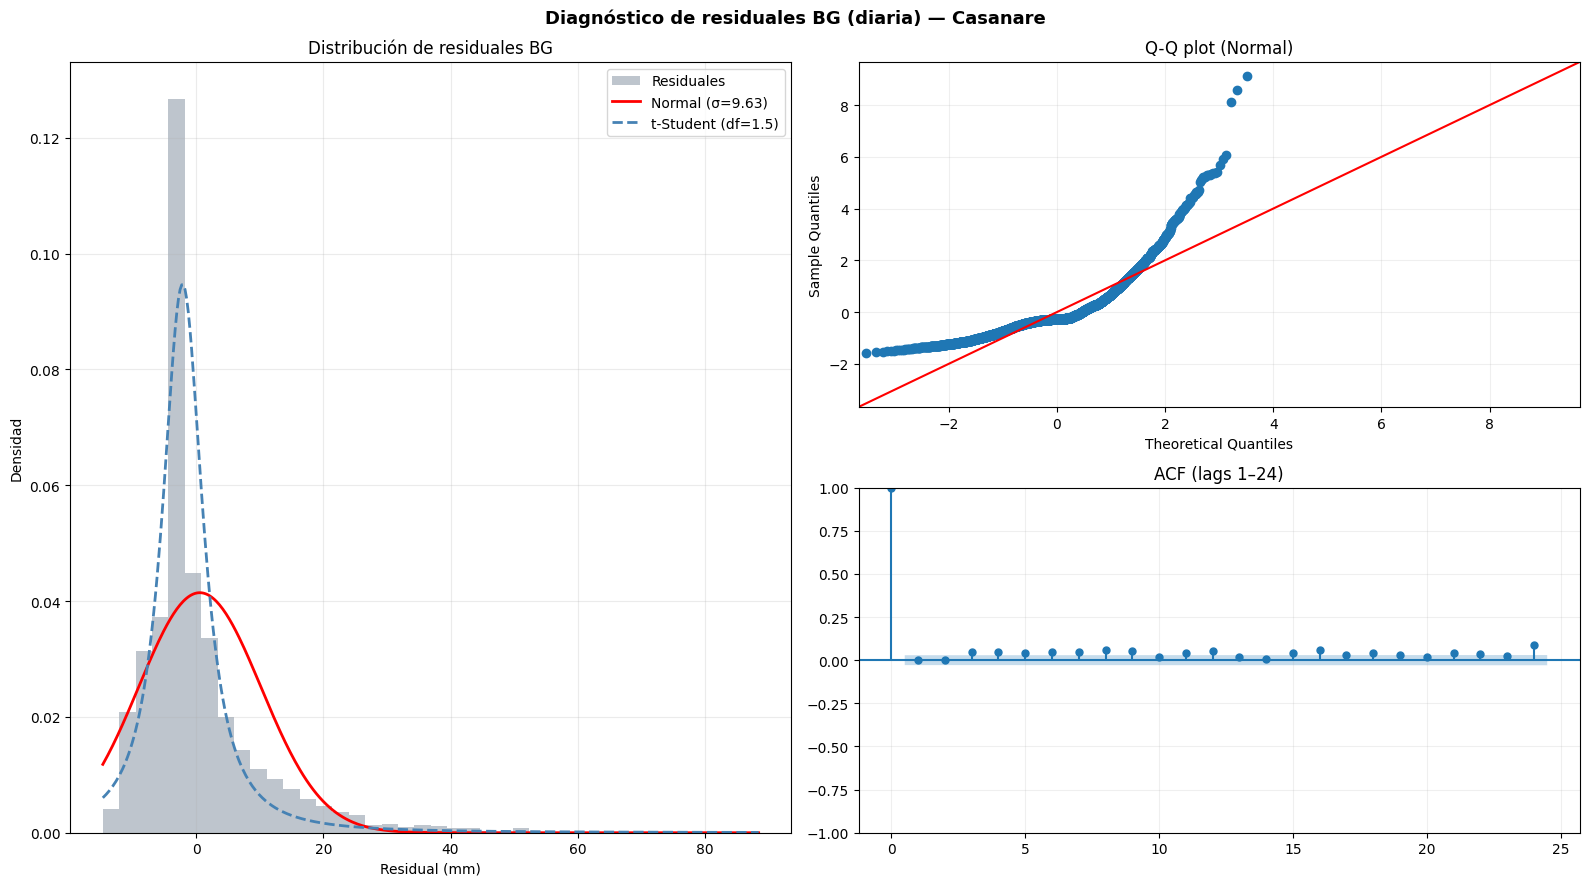

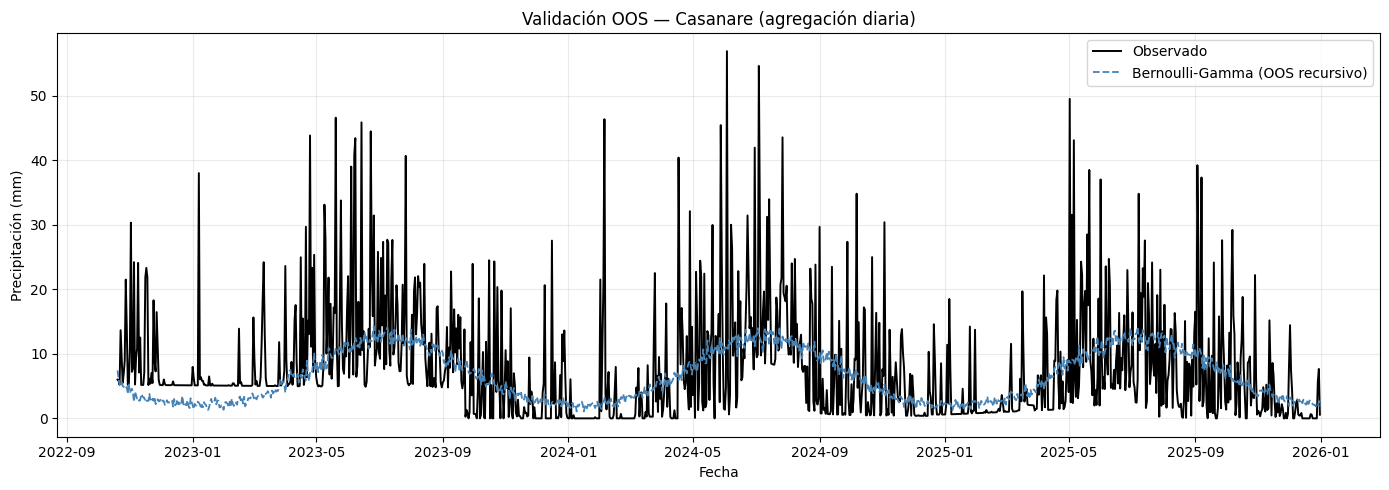


  BERNOULLI-GAMMA | TOLIMA | umbral=5 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0821
[2] Gamma (intensidad): scale (φ) = 0.3384

   [Logit] coeficientes:
               coef  std_err        z   p>|z|
const       -1.2193   0.0473 -25.8036  0.0000
sin_year     0.1047   0.0454   2.3070  0.0211
cos_year     0.3651   0.0463   7.8835  0.0000
lag1_precip  0.0651   0.0047  13.9591  0.0000
lag2_precip  0.0422   0.0044   9.5422  0.0000

   [Gamma] coeficientes:
               coef  std_err         z   p>|z|
const        2.5032   0.0235  106.3649  0.0000
sin_year     0.0231   0.0192    1.2023  0.2292
cos_year    -0.1094   0.0225   -4.8551  0.0000
lag1_precip -0.0002   0.0018   -0.0971  0.9227
lag2_precip  0.0090   0.0018    5.0599  0.0000

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10819.51,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.8813,  σ=6.9725      AIC=31415.1
   t-Student : df=1.17, loc=-1.9548, scale=2.1318  AIC=29162.3
   → Selección A

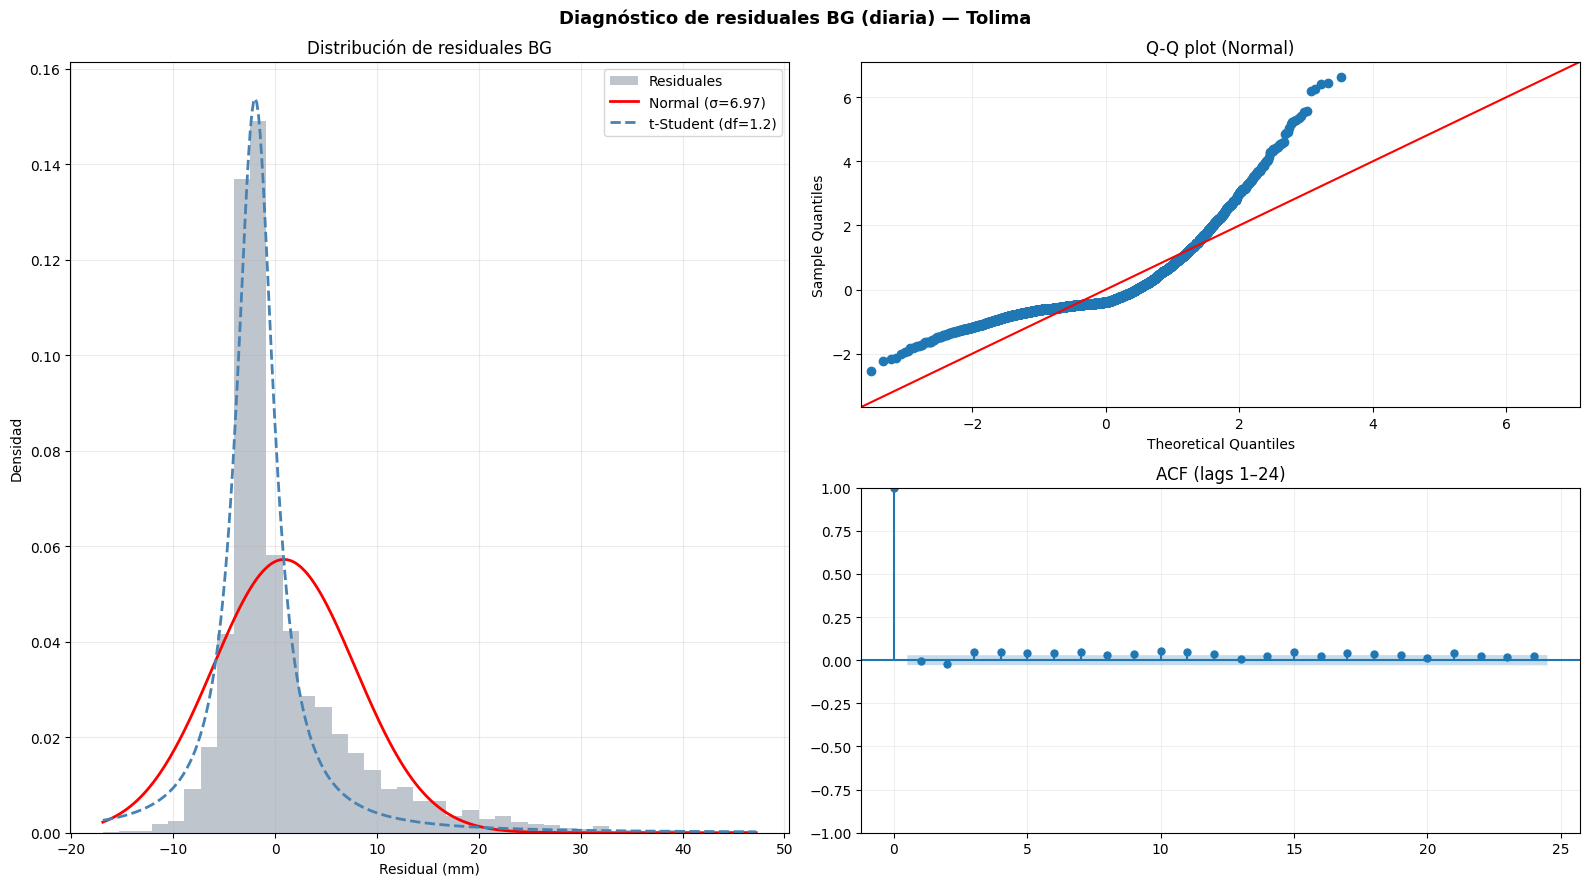

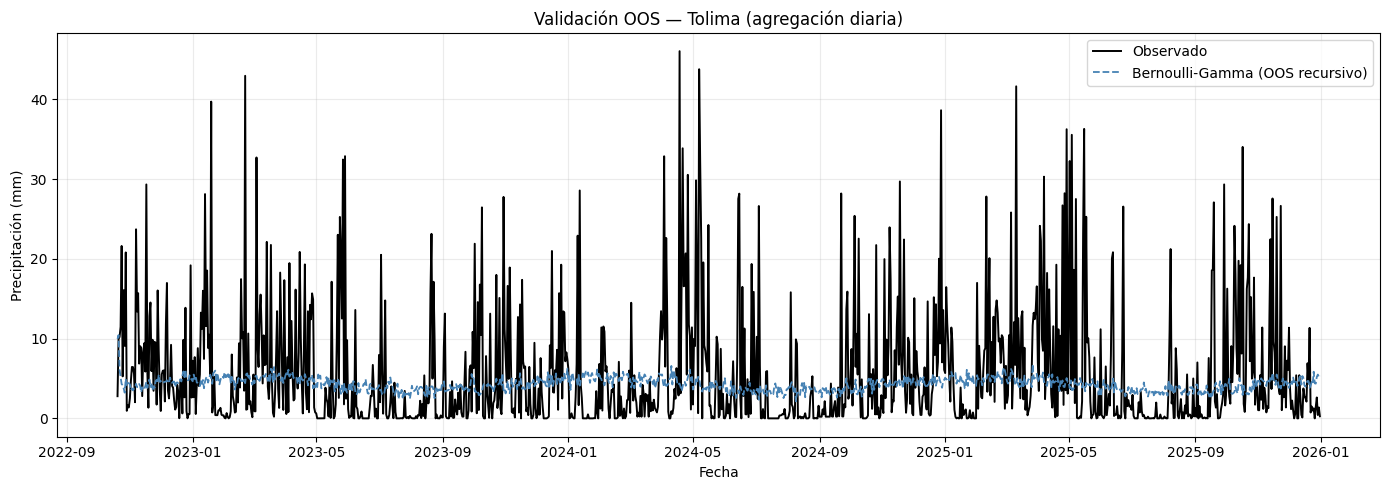

In [11]:
res_casanare = ajustar_bernoulli_gamma(df_Casanare, 'Casanare', frecuencia='diaria', threshold=5)
res_tolima   = ajustar_bernoulli_gamma(df_Tolima,   'Tolima',   frecuencia='diaria', threshold=5)

## Sensibilidad al umbral de "día lluvioso"

El umbral de 5 mm es un convenio. Se reportan MAE/RMSE OOS para 1, 5 y 10 mm como verificación.


  BERNOULLI-GAMMA | CASANARE | umbral=1 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.2338
[2] Gamma (intensidad): scale (φ) = 0.8610

   [Logit] coeficientes:
               coef  std_err        z   p>|z|
const        0.1357   0.0529   2.5651  0.0103
sin_year    -0.3942   0.0489  -8.0629  0.0000
cos_year    -1.2771   0.0596 -21.4381  0.0000
lag1_precip  0.0639   0.0055  11.6186  0.0000
lag2_precip  0.0169   0.0042   4.0227  0.0001

   [Gamma] coeficientes:
               coef  std_err        z   p>|z|
const        2.3598   0.0276  85.5807  0.0000
sin_year    -0.0033   0.0238  -0.1385  0.8899
cos_year    -0.2867   0.0288  -9.9619  0.0000
lag1_precip  0.0016   0.0016   0.9775  0.3283
lag2_precip  0.0005   0.0016   0.2994  0.7647

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19434.56,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.0430,  σ=9.5673      AIC=34371.9
   t-Student : df=1.58, loc=-2.3564, scale=3.8346  AIC=32284.1
   → Selección AIC: 

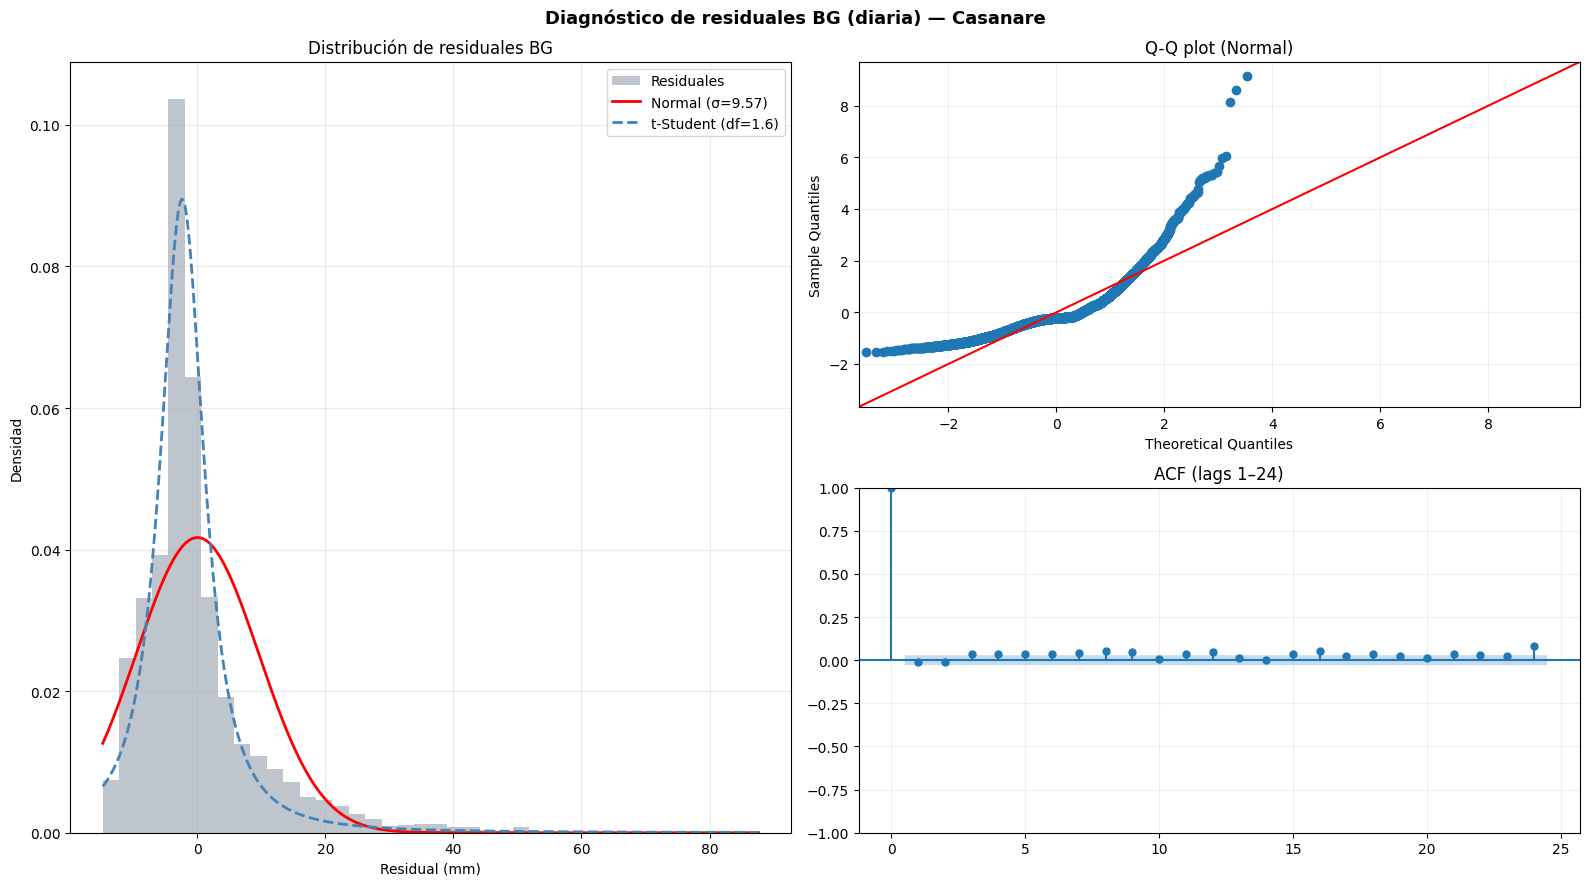

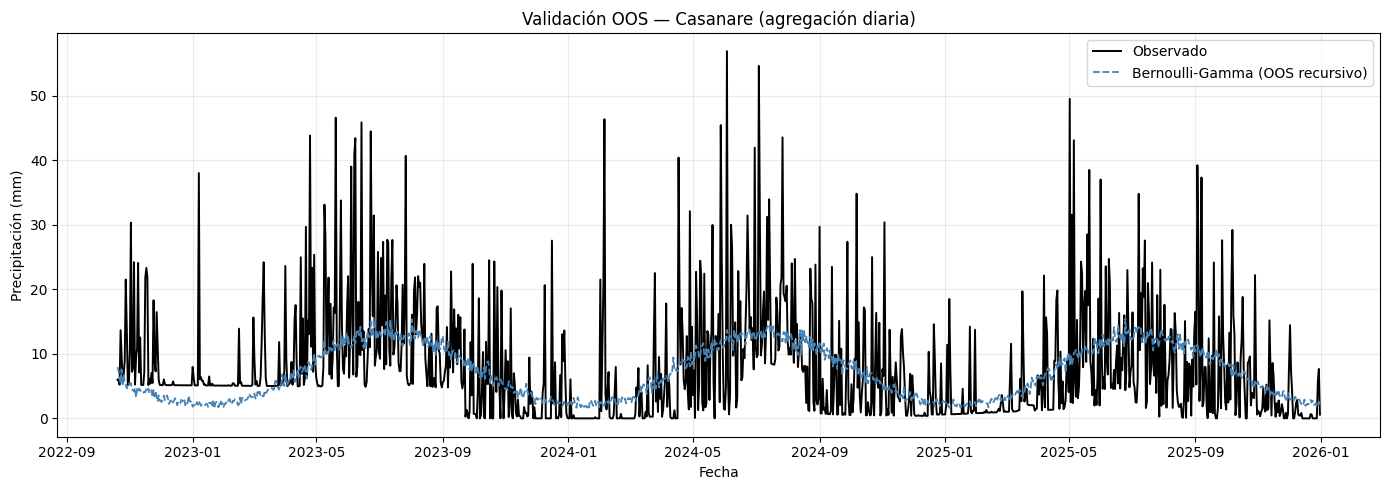


  BERNOULLI-GAMMA | TOLIMA | umbral=1 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1597
[2] Gamma (intensidad): scale (φ) = 0.8300

   [Logit] coeficientes:
               coef  std_err        z   p>|z|
const       -0.2049   0.0468  -4.3809  0.0000
sin_year     0.1391   0.0489   2.8436  0.0045
cos_year     0.5348   0.0479  11.1562  0.0000
lag1_precip  0.1403   0.0085  16.5753  0.0000
lag2_precip  0.0554   0.0061   9.1005  0.0000

   [Gamma] coeficientes:
               coef  std_err        z   p>|z|
const        1.9382   0.0259  74.9766  0.0000
sin_year     0.0339   0.0228   1.4864  0.1372
cos_year    -0.0521   0.0247  -2.1078  0.0351
lag1_precip  0.0102   0.0021   4.7510  0.0000
lag2_precip  0.0155   0.0022   7.1207  0.0000

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10888.42,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.0844,  σ=6.9173      AIC=31340.8
   t-Student : df=1.35, loc=-2.3539, scale=2.4313  AIC=29207.7
   → Selección AIC: t-

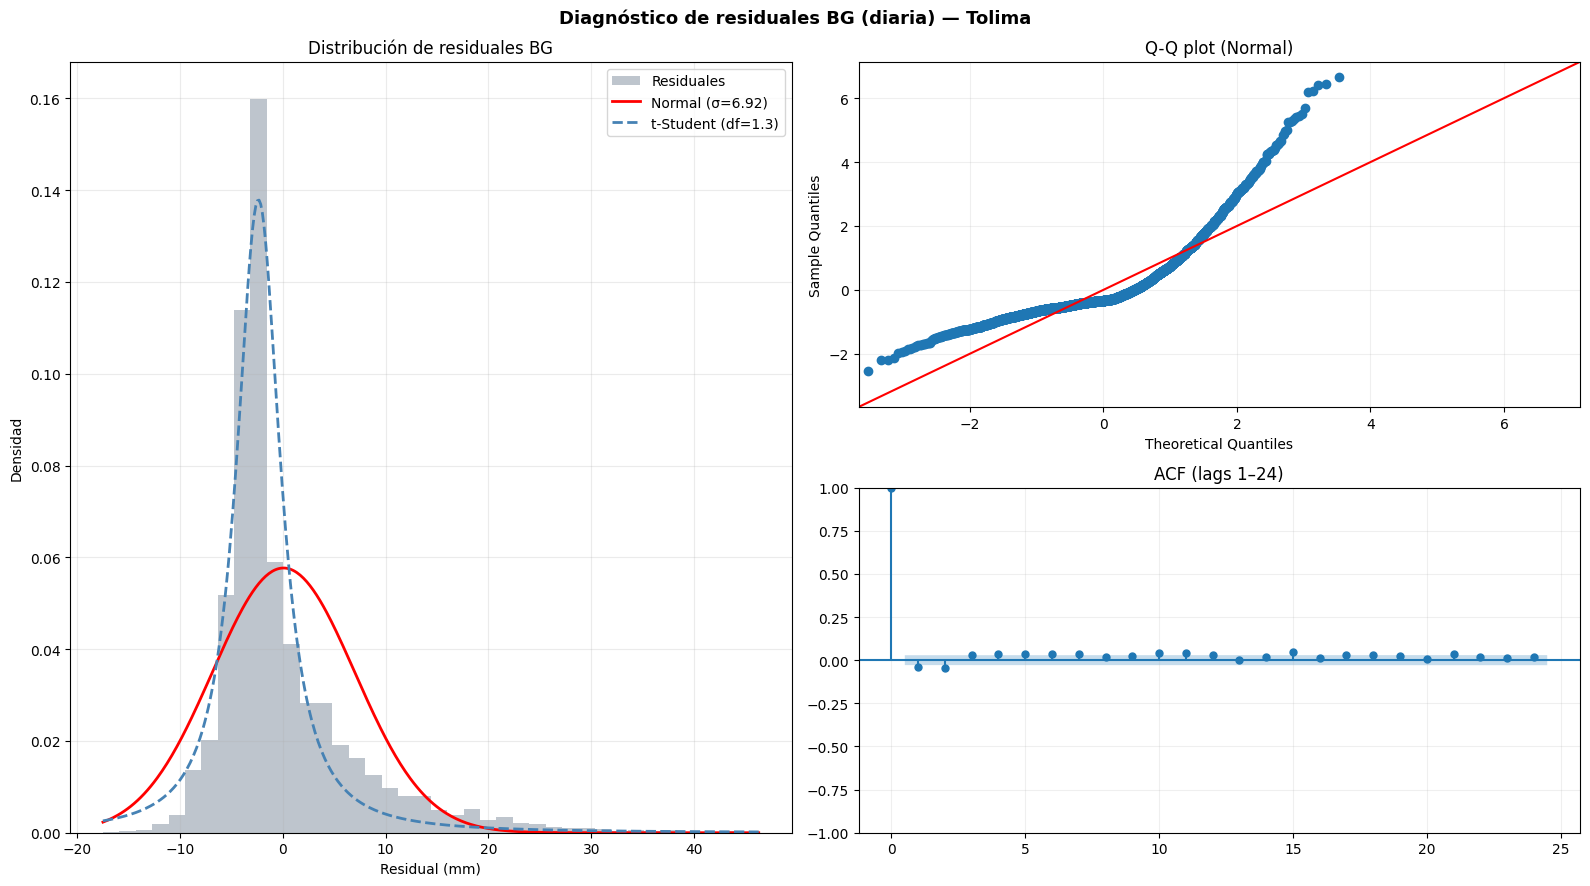

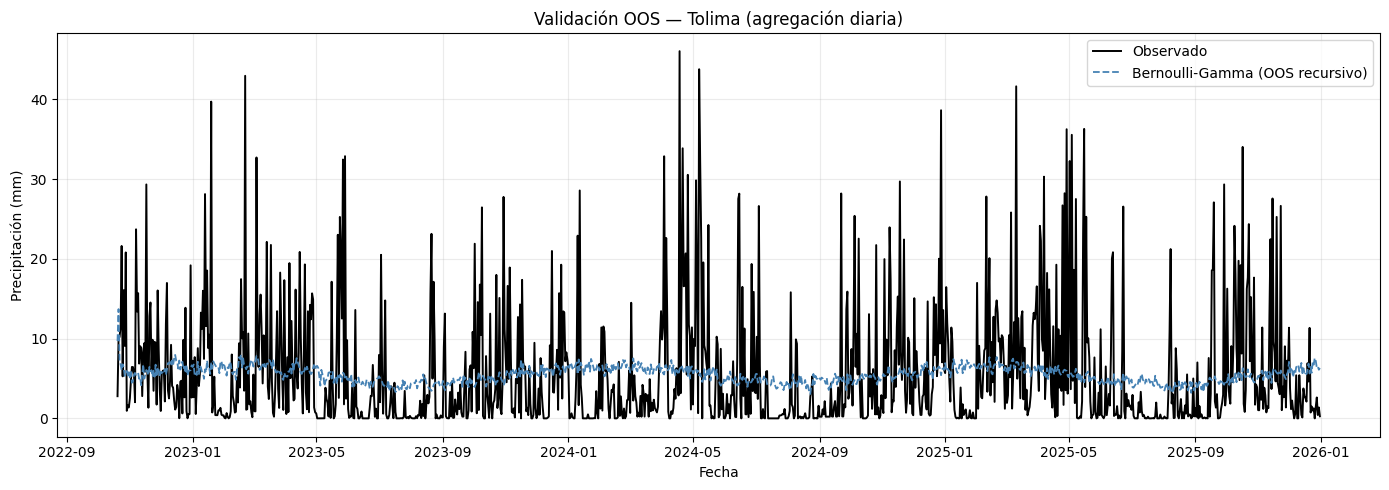


  BERNOULLI-GAMMA | CASANARE | umbral=3 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1708
[2] Gamma (intensidad): scale (φ) = 0.6051

   [Logit] coeficientes:
               coef  std_err        z  p>|z|
const       -0.3524   0.0479  -7.3522    0.0
sin_year    -0.2755   0.0450  -6.1220    0.0
cos_year    -1.1139   0.0534 -20.8533    0.0
lag1_precip  0.0384   0.0039   9.7720    0.0
lag2_precip  0.0155   0.0035   4.4004    0.0

   [Gamma] coeficientes:
               coef  std_err        z   p>|z|
const        2.5798   0.0263  98.2250  0.0000
sin_year     0.0053   0.0222   0.2387  0.8113
cos_year    -0.2123   0.0272  -7.8187  0.0000
lag1_precip  0.0000   0.0015   0.0233  0.9814
lag2_precip -0.0008   0.0015  -0.5608  0.5749

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19338.07,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.2712,  σ=9.6056      AIC=34409.3
   t-Student : df=1.51, loc=-2.2899, scale=3.7032  AIC=32276.9
   → Selección AIC: t-Stud

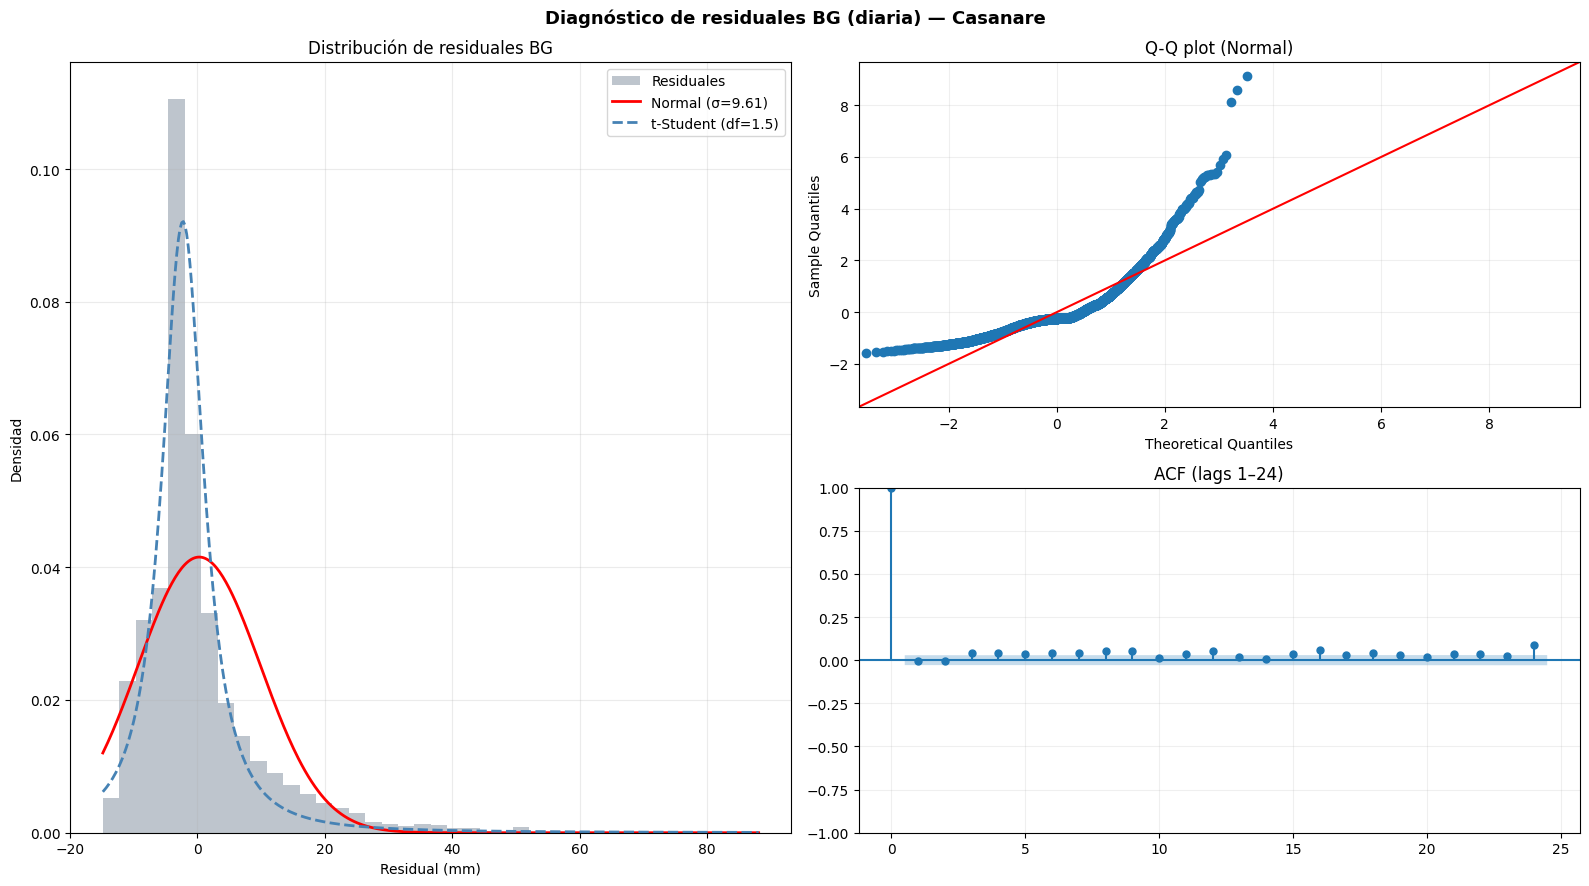

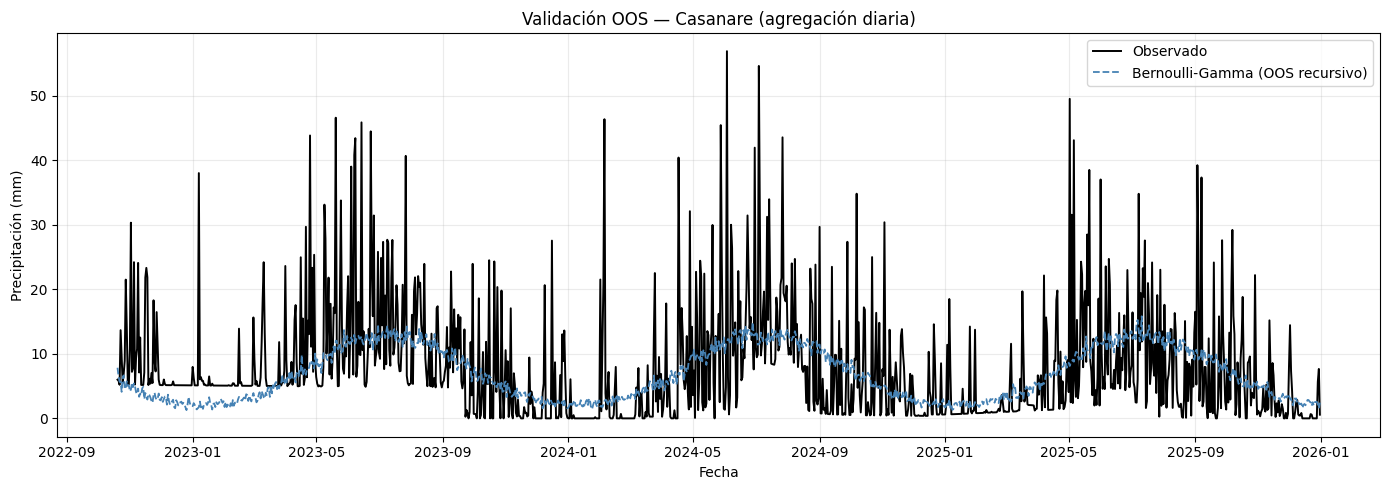


  BERNOULLI-GAMMA | TOLIMA | umbral=3 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1149
[2] Gamma (intensidad): scale (φ) = 0.4996

   [Logit] coeficientes:
               coef  std_err        z   p>|z|
const       -0.8441   0.0455 -18.5585  0.0000
sin_year     0.1194   0.0450   2.6559  0.0079
cos_year     0.4226   0.0451   9.3733  0.0000
lag1_precip  0.0889   0.0055  16.2080  0.0000
lag2_precip  0.0495   0.0048  10.3155  0.0000

   [Gamma] coeficientes:
               coef  std_err        z   p>|z|
const        2.2924   0.0246  93.3455  0.0000
sin_year     0.0262   0.0205   1.2787  0.2010
cos_year    -0.0895   0.0231  -3.8711  0.0001
lag1_precip  0.0018   0.0019   0.9456  0.3444
lag2_precip  0.0101   0.0019   5.3419  0.0000

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10924.12,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.4257,  σ=6.9362      AIC=31366.4
   t-Student : df=1.26, loc=-2.1879, scale=2.2828  AIC=29172.0
   → Selección AIC: t-

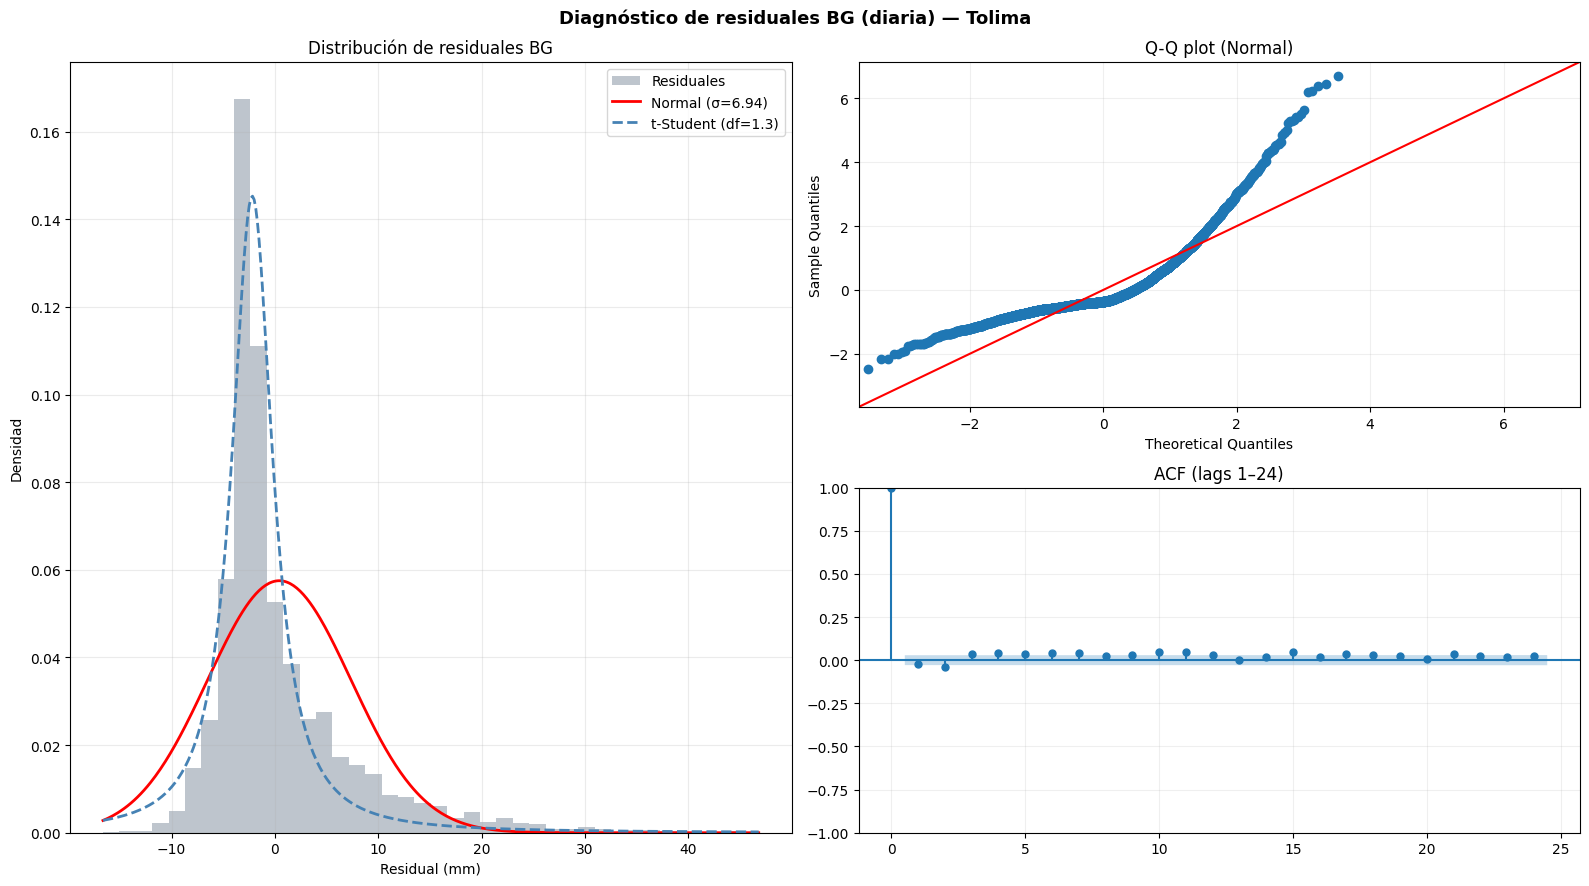

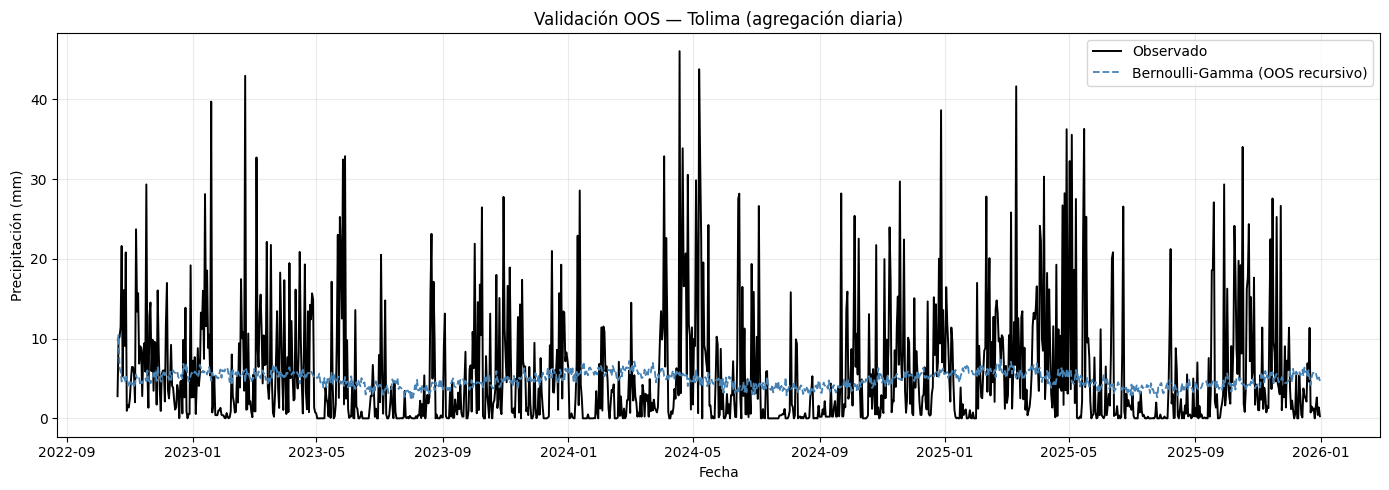


  BERNOULLI-GAMMA | CASANARE | umbral=5 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1444
[2] Gamma (intensidad): scale (φ) = 0.4858

   [Logit] coeficientes:
               coef  std_err        z  p>|z|
const       -0.6518   0.0474 -13.7434    0.0
sin_year    -0.2544   0.0446  -5.6993    0.0
cos_year    -1.0286   0.0525 -19.5796    0.0
lag1_precip  0.0317   0.0035   8.9660    0.0
lag2_precip  0.0144   0.0033   4.3523    0.0

   [Gamma] coeficientes:
               coef  std_err         z   p>|z|
const        2.7164   0.0259  104.9636  0.0000
sin_year     0.0168   0.0215    0.7832  0.4335
cos_year    -0.1855   0.0264   -7.0298  0.0000
lag1_precip -0.0010   0.0014   -0.6839  0.4941
lag2_precip -0.0016   0.0015   -1.1219  0.2619

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19418.62,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.5585,  σ=9.6257      AIC=34428.8
   t-Student : df=1.45, loc=-2.1507, scale=3.5803  AIC=32247.6
   → Selección AIC: 

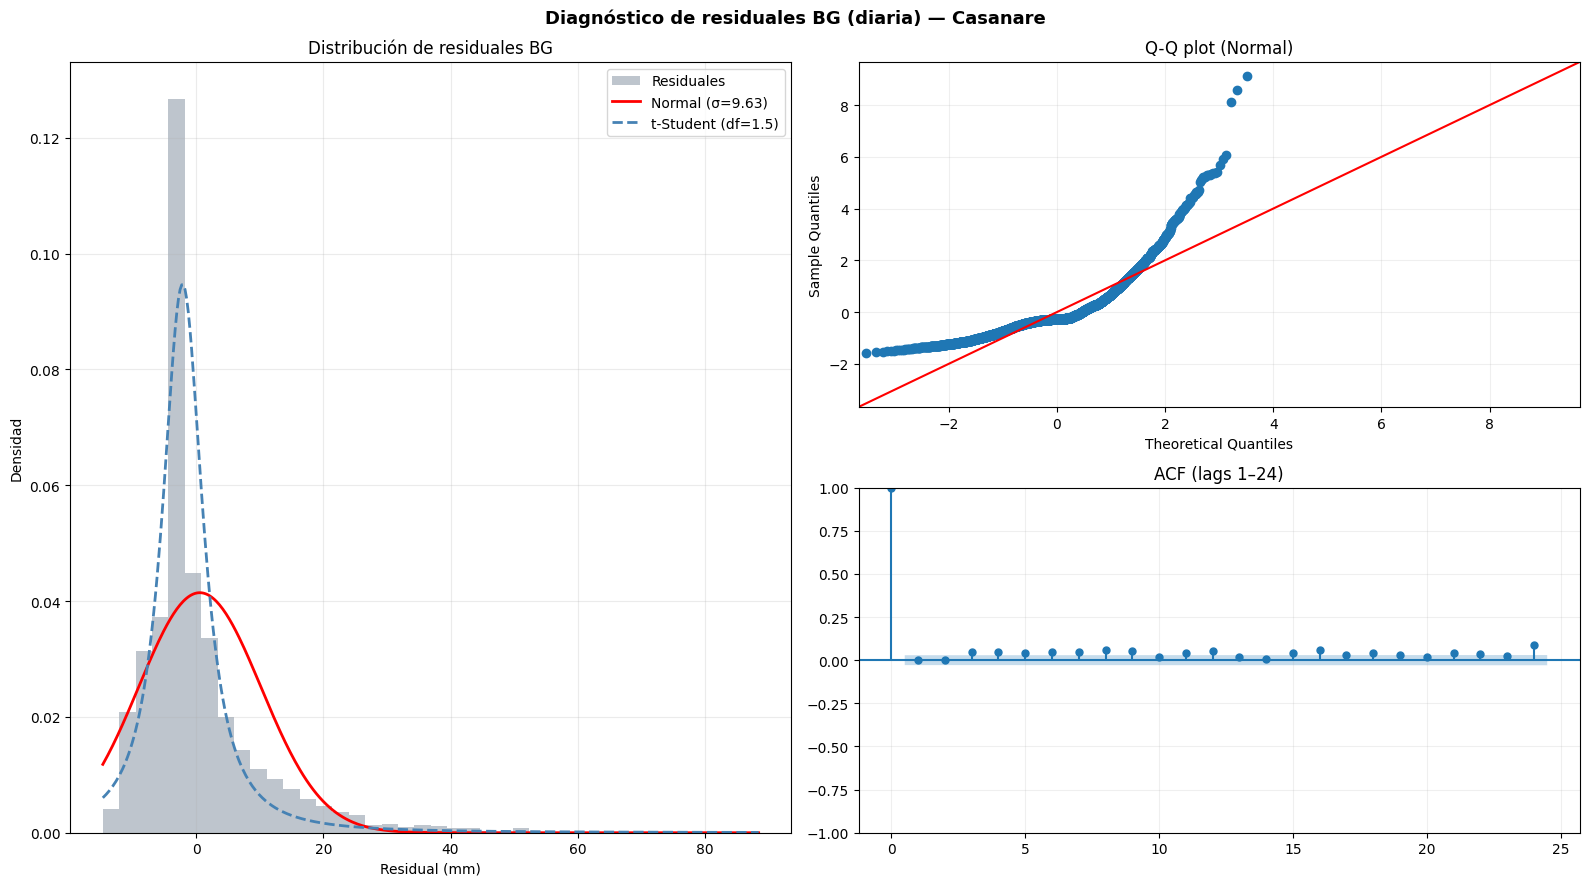

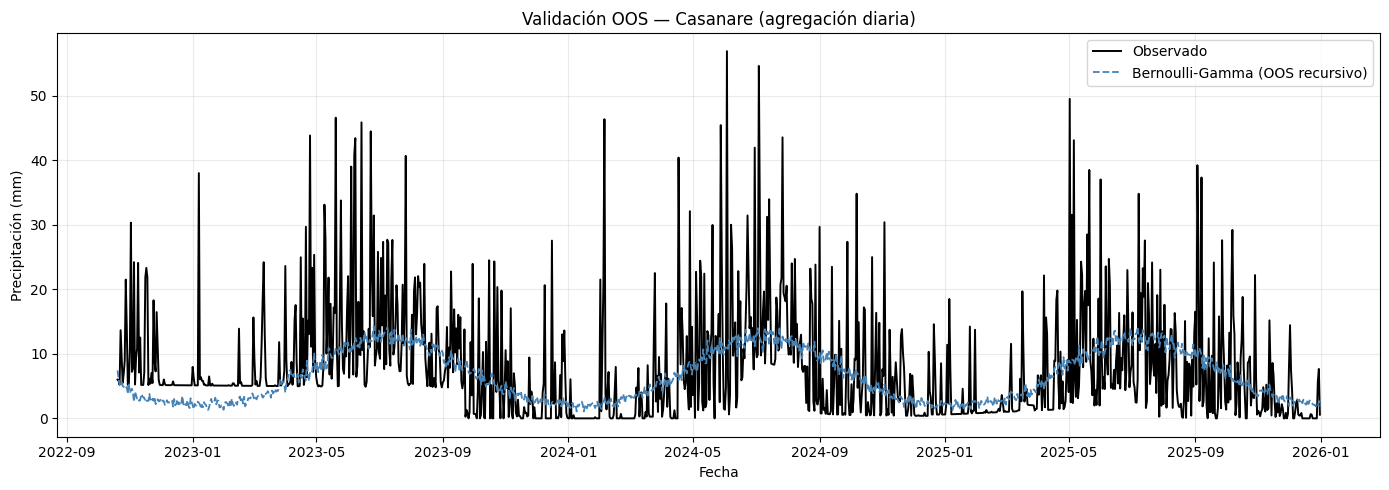


  BERNOULLI-GAMMA | TOLIMA | umbral=5 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0821
[2] Gamma (intensidad): scale (φ) = 0.3384

   [Logit] coeficientes:
               coef  std_err        z   p>|z|
const       -1.2193   0.0473 -25.8036  0.0000
sin_year     0.1047   0.0454   2.3070  0.0211
cos_year     0.3651   0.0463   7.8835  0.0000
lag1_precip  0.0651   0.0047  13.9591  0.0000
lag2_precip  0.0422   0.0044   9.5422  0.0000

   [Gamma] coeficientes:
               coef  std_err         z   p>|z|
const        2.5032   0.0235  106.3649  0.0000
sin_year     0.0231   0.0192    1.2023  0.2292
cos_year    -0.1094   0.0225   -4.8551  0.0000
lag1_precip -0.0002   0.0018   -0.0971  0.9227
lag2_precip  0.0090   0.0018    5.0599  0.0000

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10819.51,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.8813,  σ=6.9725      AIC=31415.1
   t-Student : df=1.17, loc=-1.9548, scale=2.1318  AIC=29162.3
   → Selección A

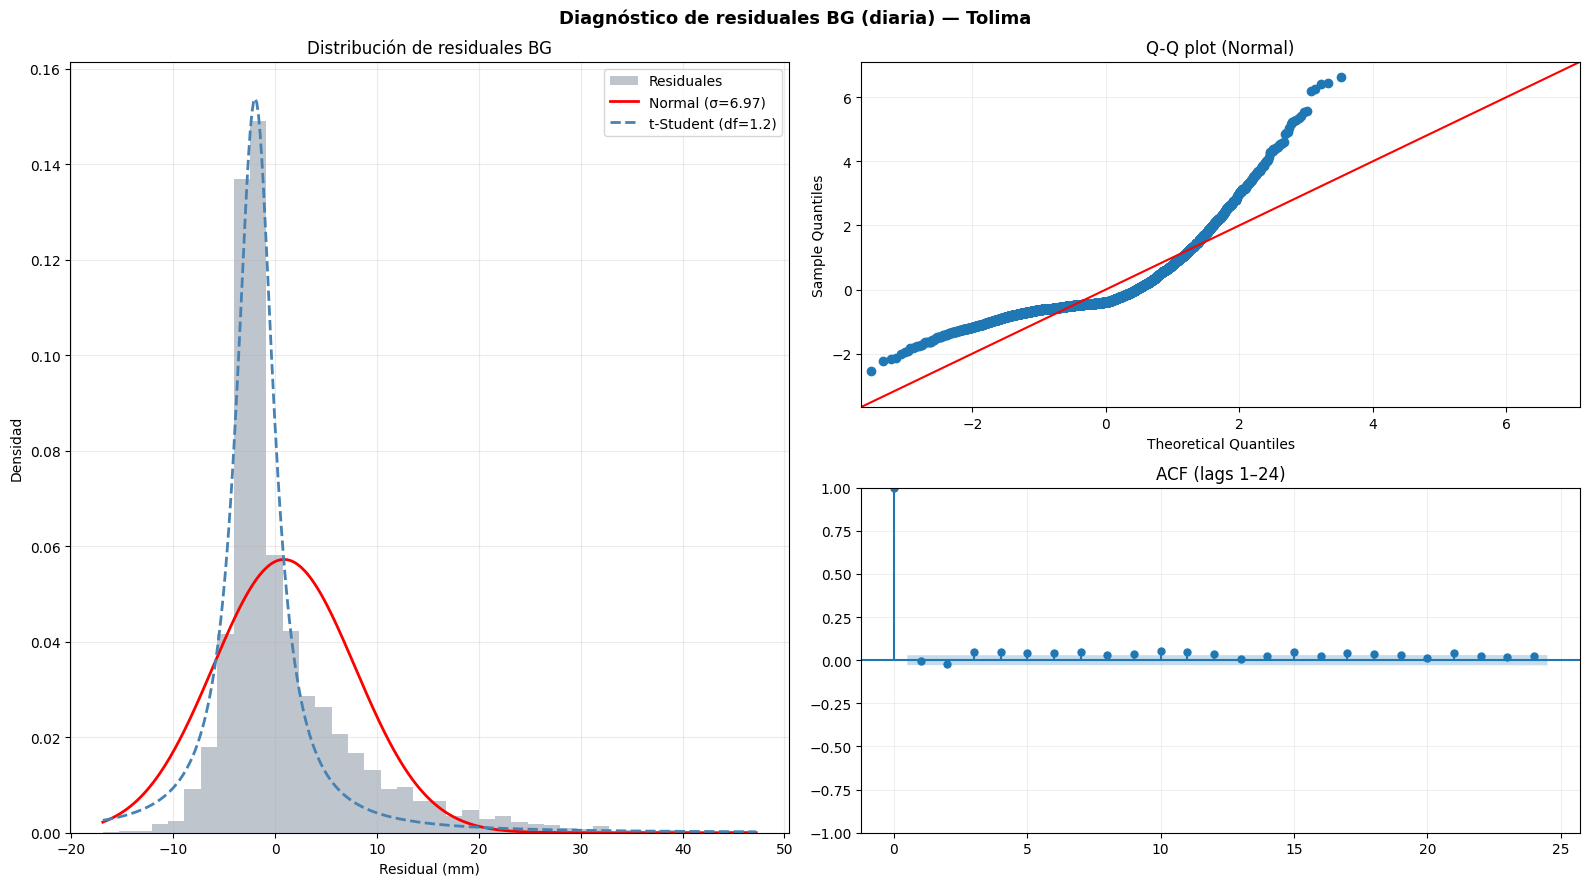

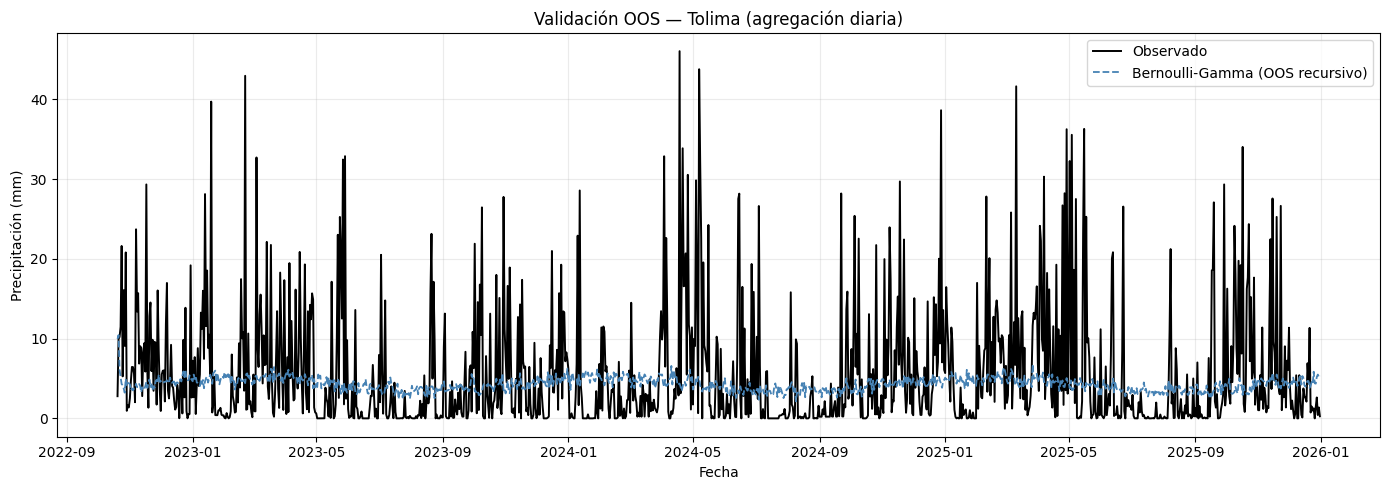


  BERNOULLI-GAMMA | CASANARE | umbral=7 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1520
[2] Gamma (intensidad): scale (φ) = 0.3510

   [Logit] coeficientes:
               coef  std_err        z   p>|z|
const       -1.0520   0.0504 -20.8888  0.0000
sin_year    -0.2699   0.0467  -5.7756  0.0000
cos_year    -1.2114   0.0562 -21.5386  0.0000
lag1_precip  0.0232   0.0033   6.9899  0.0000
lag2_precip  0.0101   0.0032   3.1236  0.0018

   [Gamma] coeficientes:
               coef  std_err         z   p>|z|
const        2.9367   0.0258  113.6714  0.0000
sin_year     0.0573   0.0207    2.7685  0.0056
cos_year    -0.0343   0.0277   -1.2379  0.2157
lag1_precip -0.0017   0.0013   -1.3003  0.1935
lag2_precip -0.0019   0.0013   -1.4412  0.1495

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19464.86,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=1.1018,  σ=9.6387      AIC=34441.4
   t-Student : df=1.42, loc=-1.7813, scale=3.5053  AIC=32230.0
   → Selección

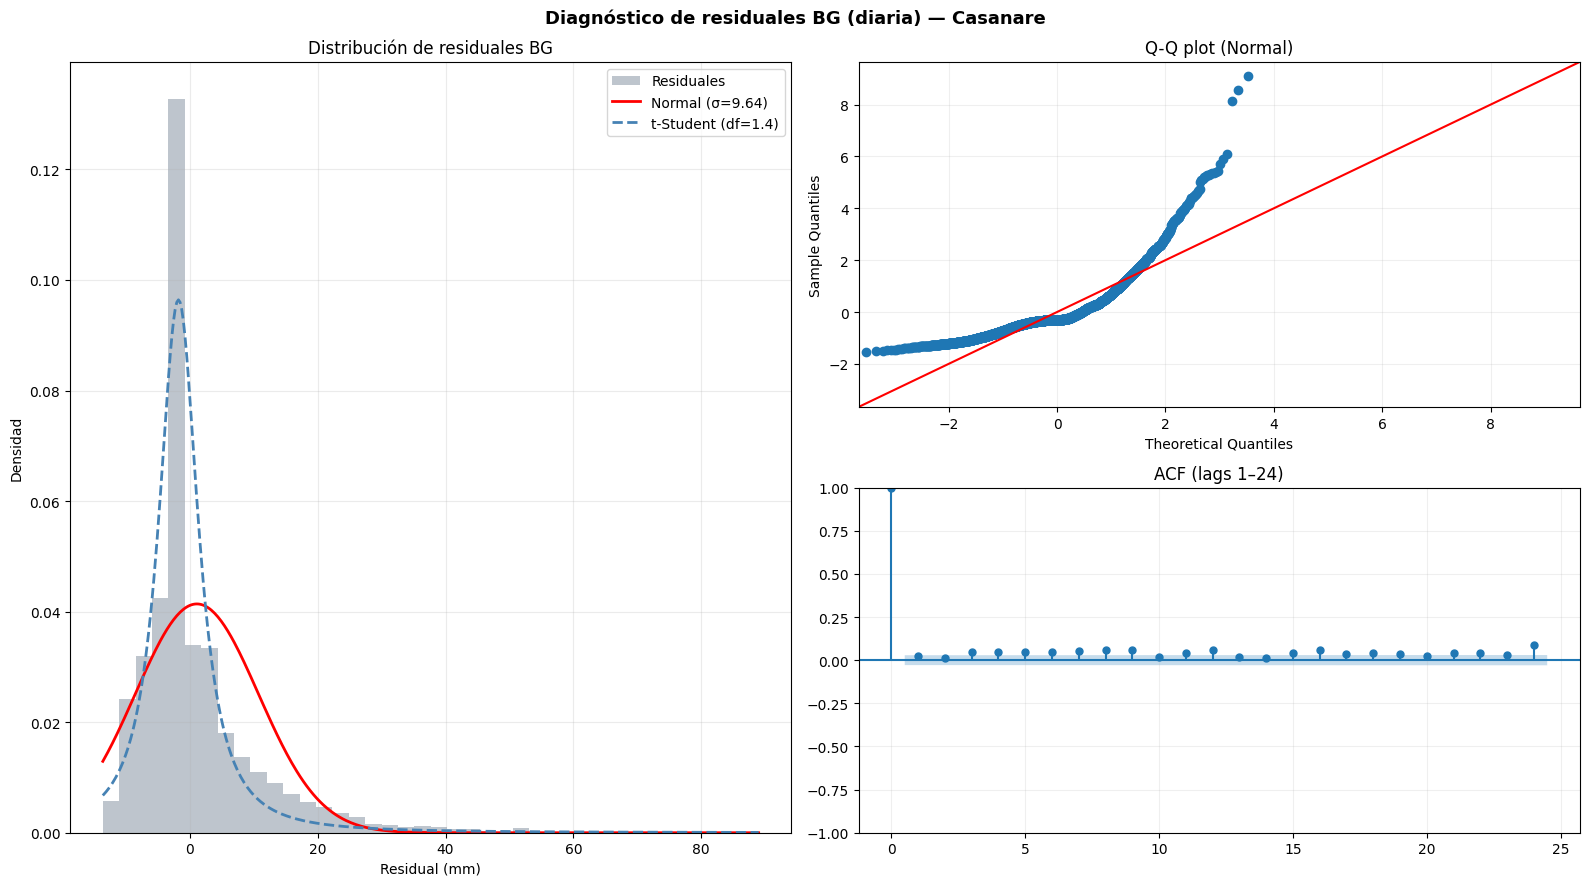

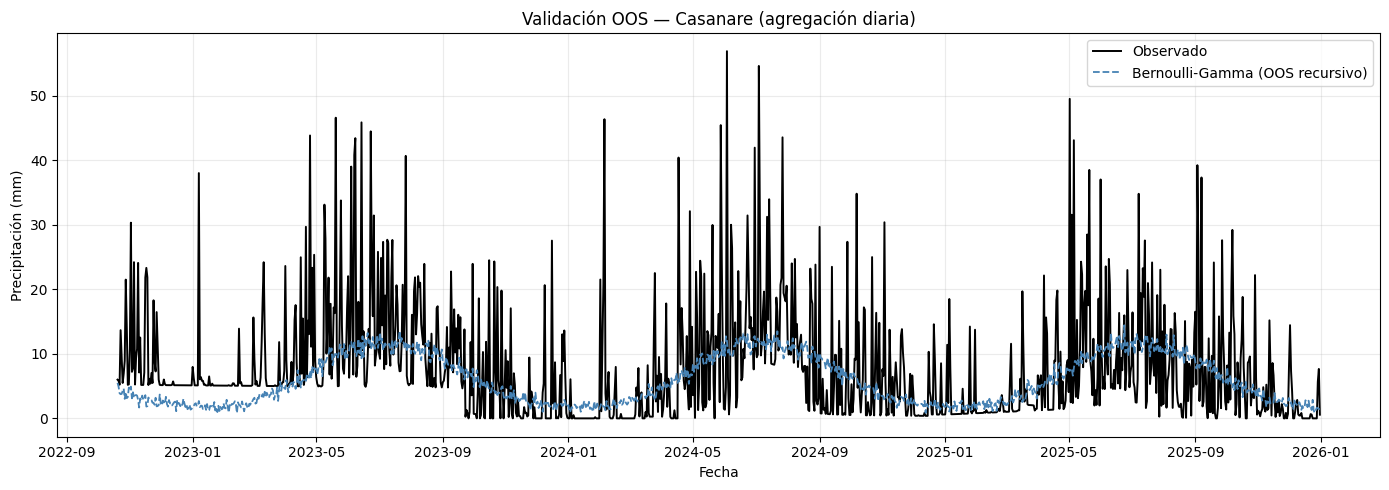


  BERNOULLI-GAMMA | TOLIMA | umbral=7 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0681
[2] Gamma (intensidad): scale (φ) = 0.2437

   [Logit] coeficientes:
               coef  std_err        z   p>|z|
const       -1.5843   0.0510 -31.0622  0.0000
sin_year     0.1306   0.0480   2.7205  0.0065
cos_year     0.2768   0.0495   5.5923  0.0000
lag1_precip  0.0542   0.0045  12.0550  0.0000
lag2_precip  0.0431   0.0044   9.7323  0.0000

   [Gamma] coeficientes:
               coef  std_err         z   p>|z|
const        2.6771   0.0235  113.8182  0.0000
sin_year     0.0149   0.0186    0.7968  0.4256
cos_year    -0.1046   0.0221   -4.7367  0.0000
lag1_precip -0.0012   0.0018   -0.6900  0.4902
lag2_precip  0.0070   0.0017    4.2065  0.0000

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10646.85,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=1.3861,  σ=6.9975      AIC=31448.5
   t-Student : df=1.13, loc=-1.6255, scale=2.0534  AIC=29188.9
   → Selección A

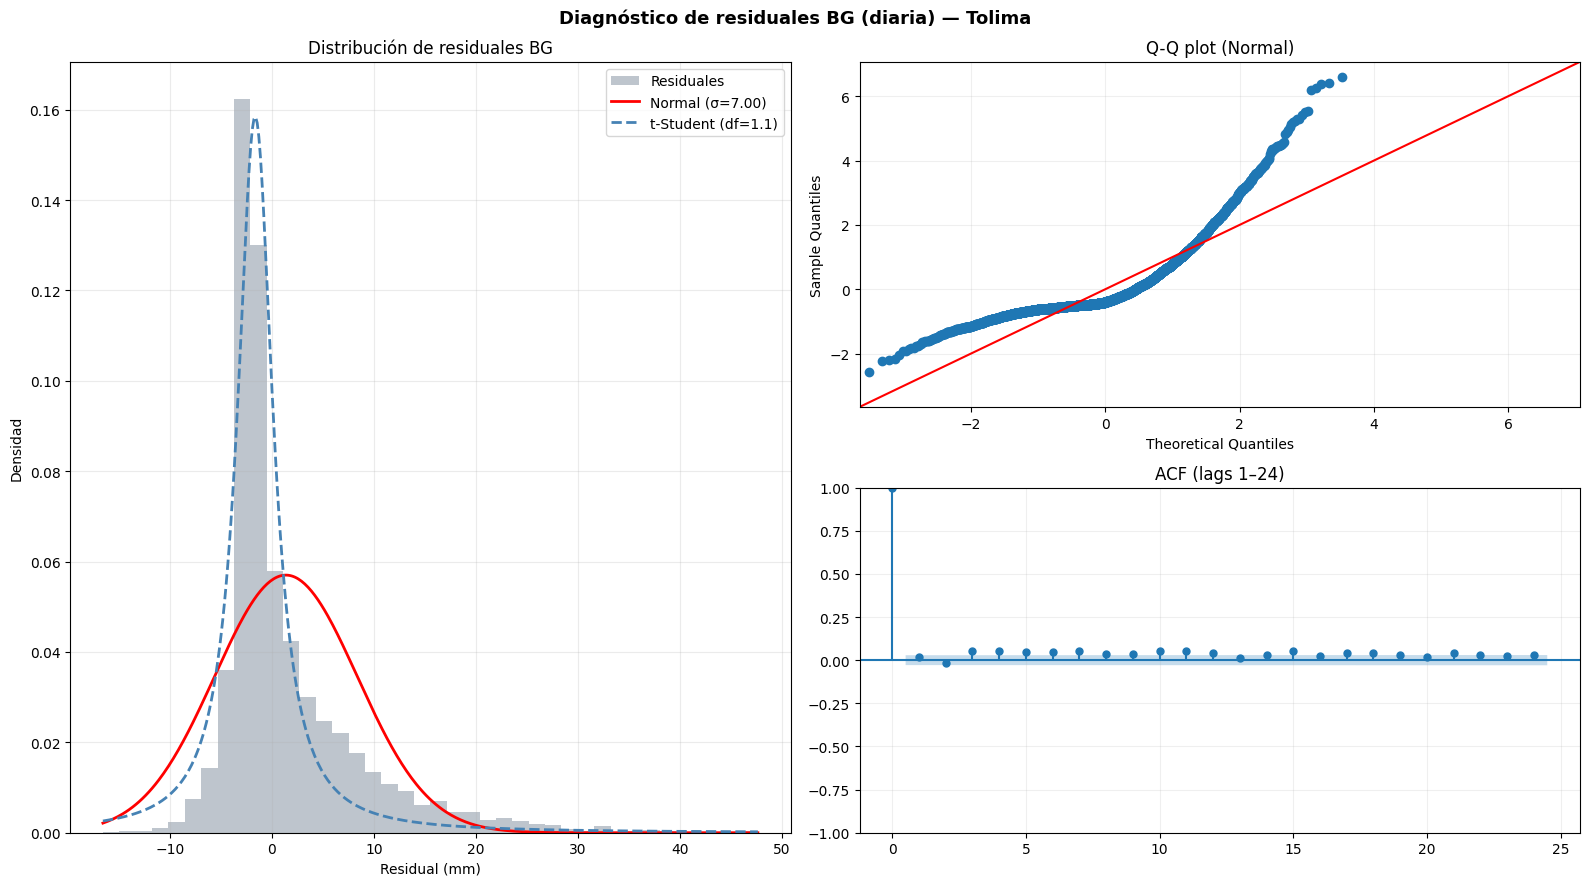

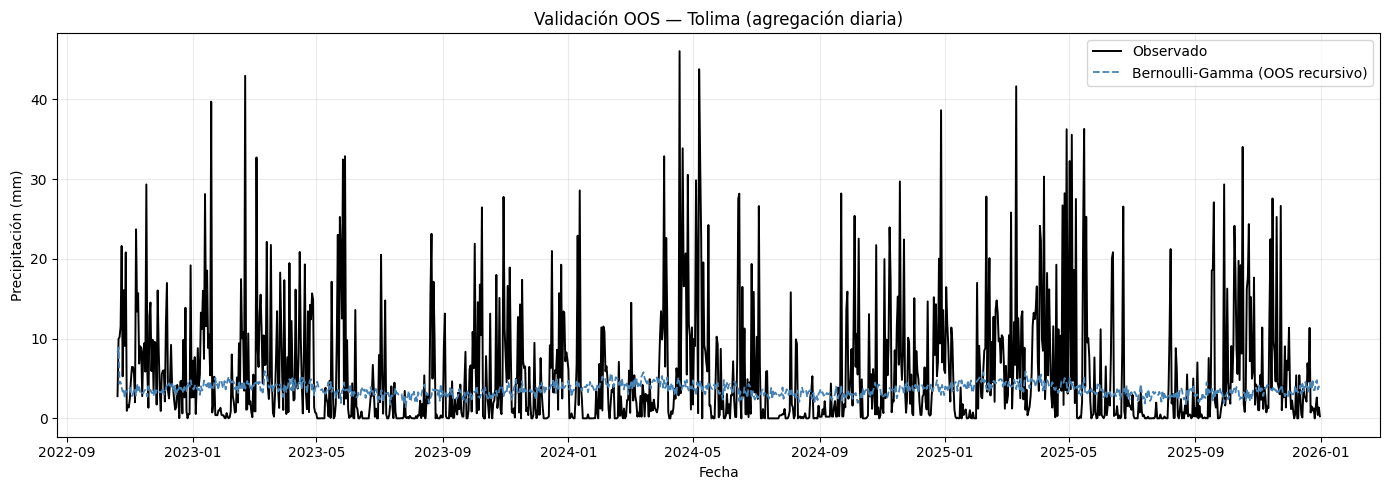


  BERNOULLI-GAMMA | CASANARE | umbral=10 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1259
[2] Gamma (intensidad): scale (φ) = 0.2621

   [Logit] coeficientes:
               coef  std_err        z   p>|z|
const       -1.3819   0.0534 -25.8663  0.0000
sin_year    -0.2291   0.0496  -4.6204  0.0000
cos_year    -1.1599   0.0597 -19.4172  0.0000
lag1_precip  0.0192   0.0033   5.8602  0.0000
lag2_precip  0.0058   0.0033   1.7489  0.0803

   [Gamma] coeficientes:
               coef  std_err         z   p>|z|
const        3.0863   0.0257  120.1890  0.0000
sin_year     0.0630   0.0202    3.1124  0.0019
cos_year     0.0044   0.0276    0.1612  0.8720
lag1_precip -0.0021   0.0013   -1.5952  0.1107
lag2_precip -0.0011   0.0013   -0.8499  0.3954

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19636.06,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=1.7352,  σ=9.6688      AIC=34470.6
   t-Student : df=1.32, loc=-1.5089, scale=3.2822  AIC=32164.2
   → Selecció

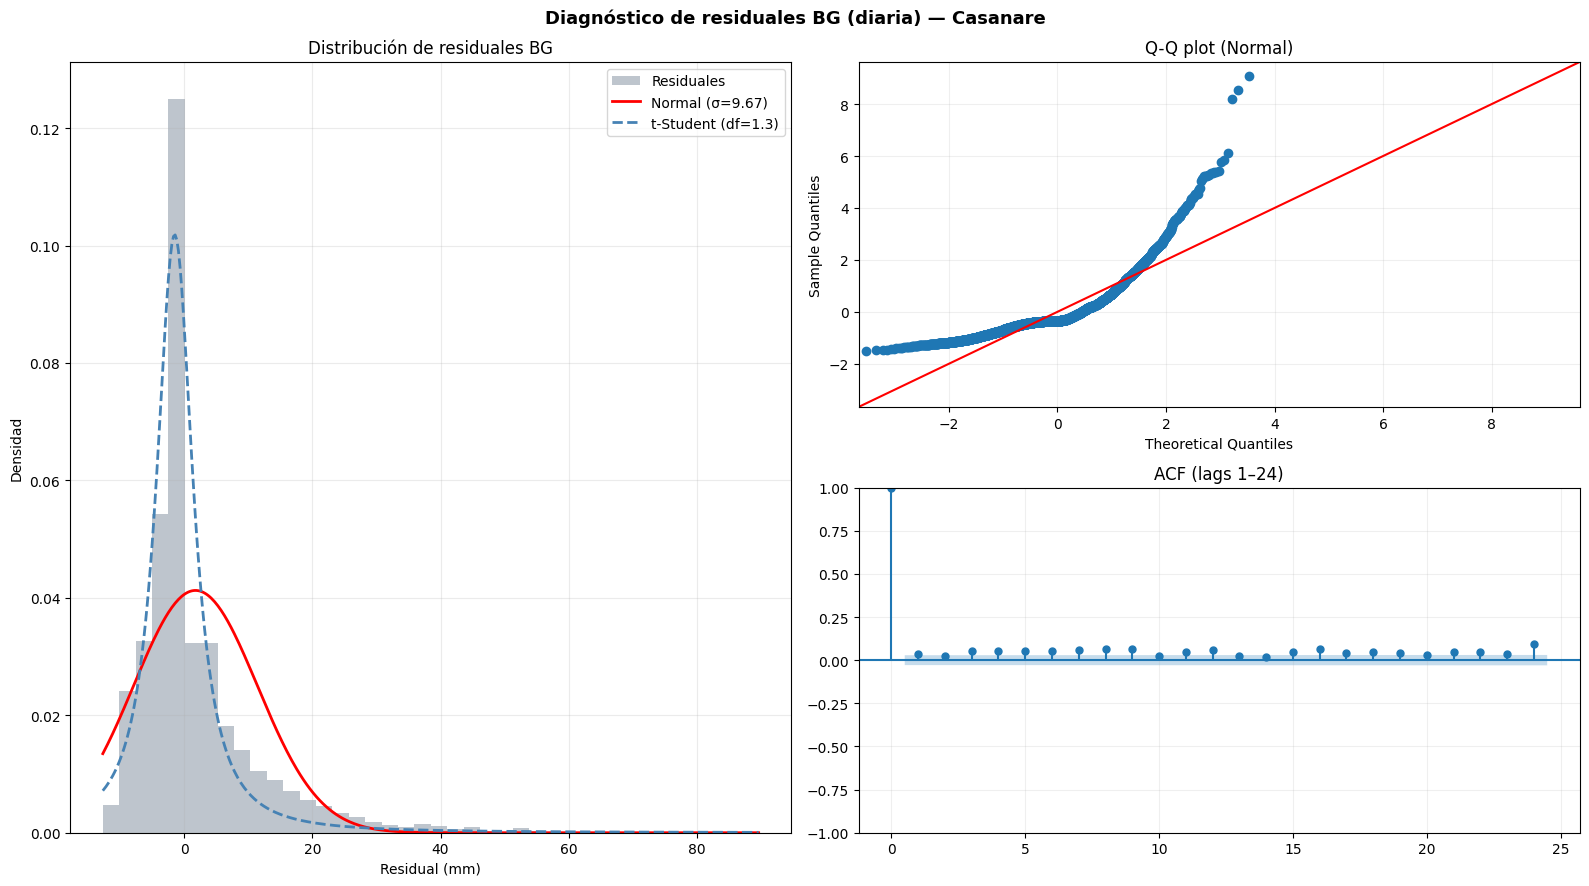

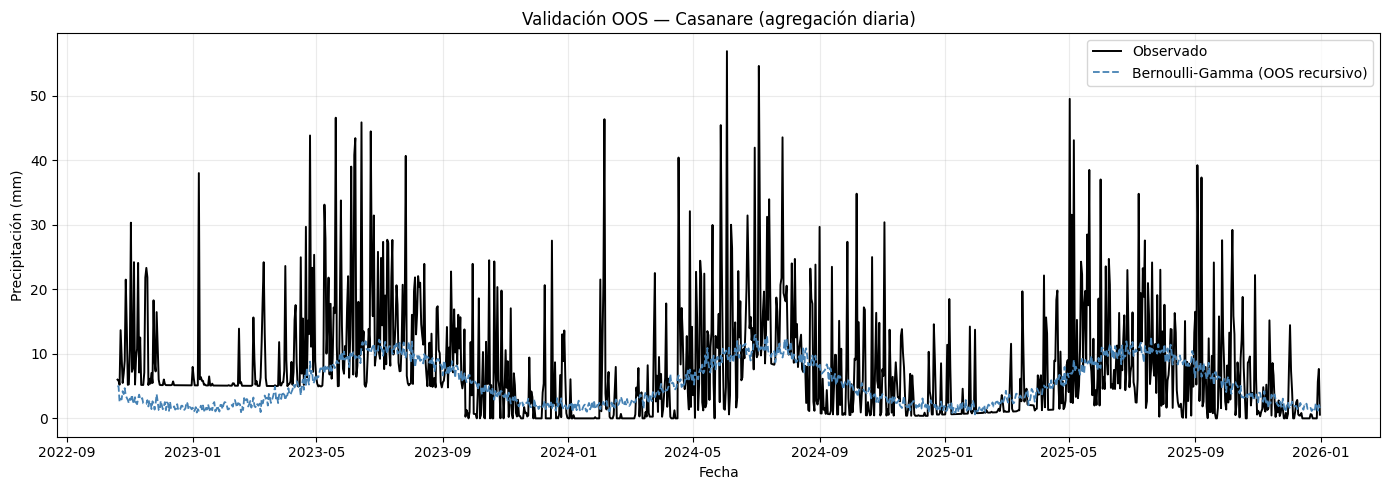


  BERNOULLI-GAMMA | TOLIMA | umbral=10 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0560
[2] Gamma (intensidad): scale (φ) = 0.1651

   [Logit] coeficientes:
               coef  std_err        z   p>|z|
const       -2.0181   0.0577 -34.9999  0.0000
sin_year     0.1503   0.0535   2.8086  0.0050
cos_year     0.1419   0.0556   2.5535  0.0107
lag1_precip  0.0447   0.0047   9.6196  0.0000
lag2_precip  0.0452   0.0046   9.7443  0.0000

   [Gamma] coeficientes:
               coef  std_err         z   p>|z|
const        2.8617   0.0232  123.1232  0.0000
sin_year     0.0153   0.0183    0.8341  0.4042
cos_year    -0.0748   0.0218   -3.4235  0.0006
lag1_precip -0.0016   0.0018   -0.8873  0.3749
lag2_precip  0.0050   0.0016    3.2173  0.0013

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10381.57,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=2.0668,  σ=7.0310      AIC=31493.1
   t-Student : df=1.10, loc=-1.1432, scale=2.0287  AIC=29268.6
   → Selección 

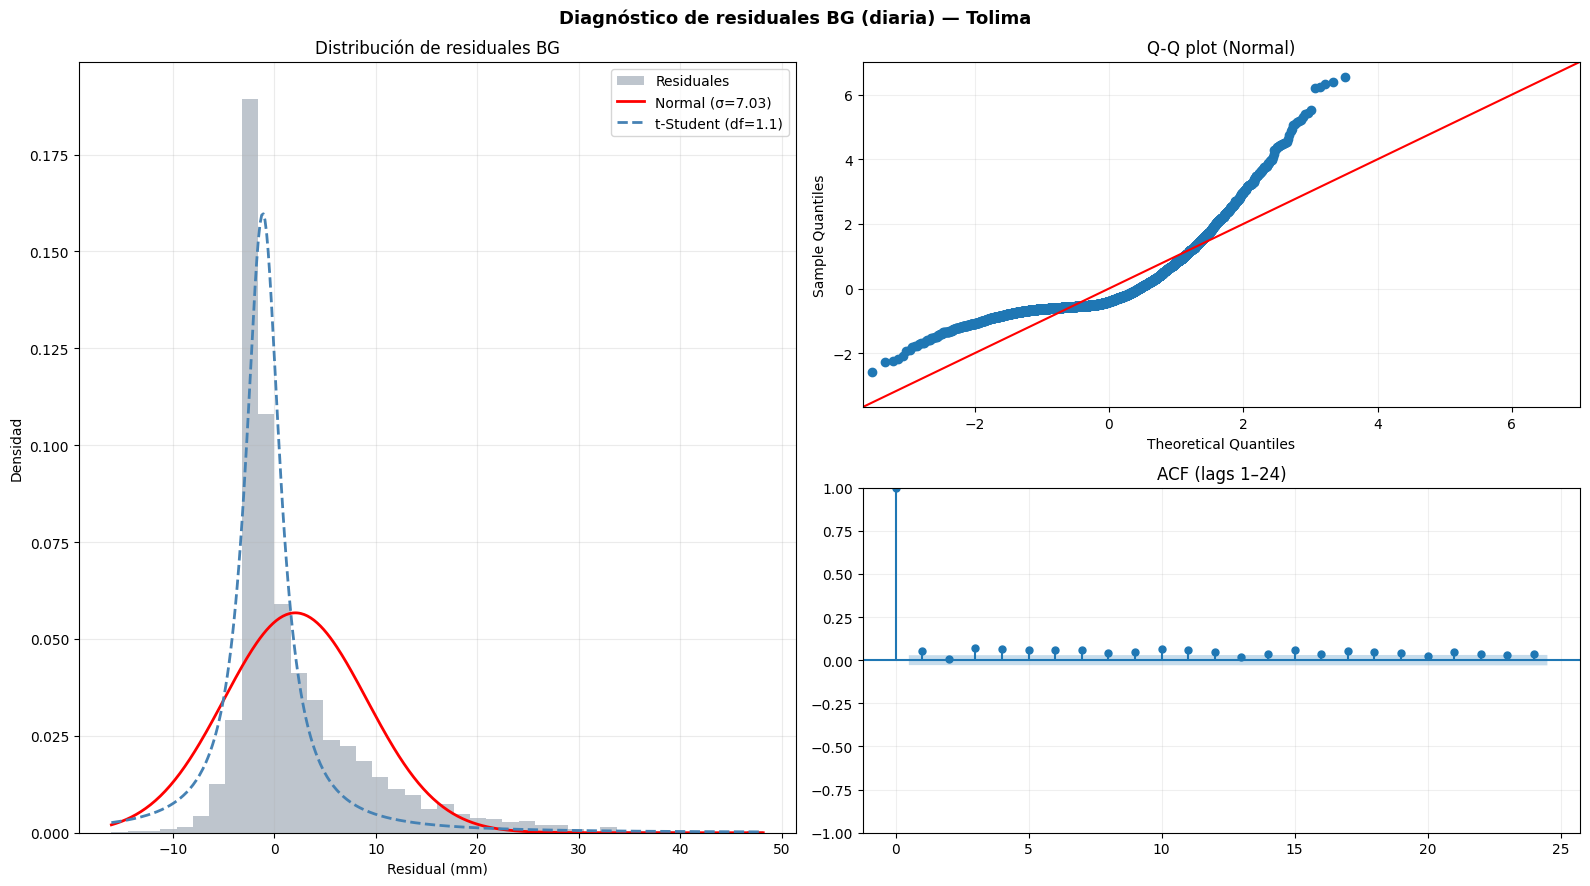

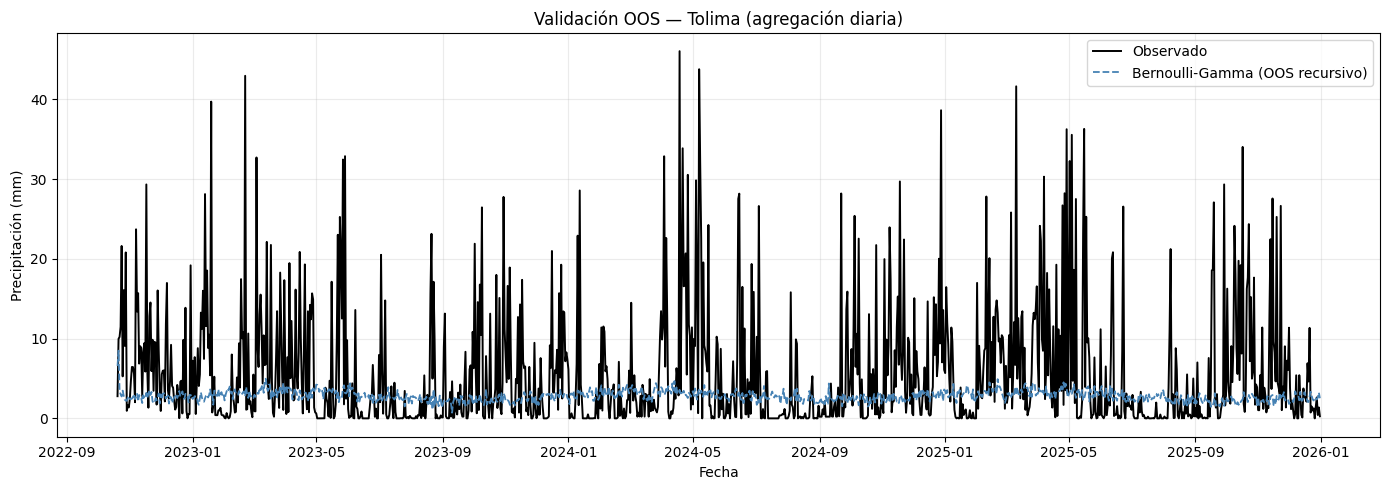


  BERNOULLI-GAMMA | CASANARE | umbral=15 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0896
[2] Gamma (intensidad): scale (φ) = 0.1698

   [Logit] coeficientes:
               coef  std_err        z   p>|z|
const       -1.9189   0.0622 -30.8465  0.0000
sin_year    -0.1110   0.0581  -1.9116  0.0559
cos_year    -1.0853   0.0701 -15.4808  0.0000
lag1_precip  0.0111   0.0036   3.0636  0.0022
lag2_precip  0.0033   0.0038   0.8784  0.3798

   [Gamma] coeficientes:
               coef  std_err         z   p>|z|
const        3.2909   0.0264  124.7108  0.0000
sin_year     0.0456   0.0205    2.2200  0.0264
cos_year     0.0336   0.0285    1.1791  0.2384
lag1_precip -0.0007   0.0014   -0.4953  0.6204
lag2_precip -0.0005   0.0014   -0.3281  0.7429

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19419.52,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=3.0009,  σ=9.7422      AIC=34541.3
   t-Student : df=1.17, loc=-0.9842, scale=2.9107  AIC=32116.7
   → Selecció

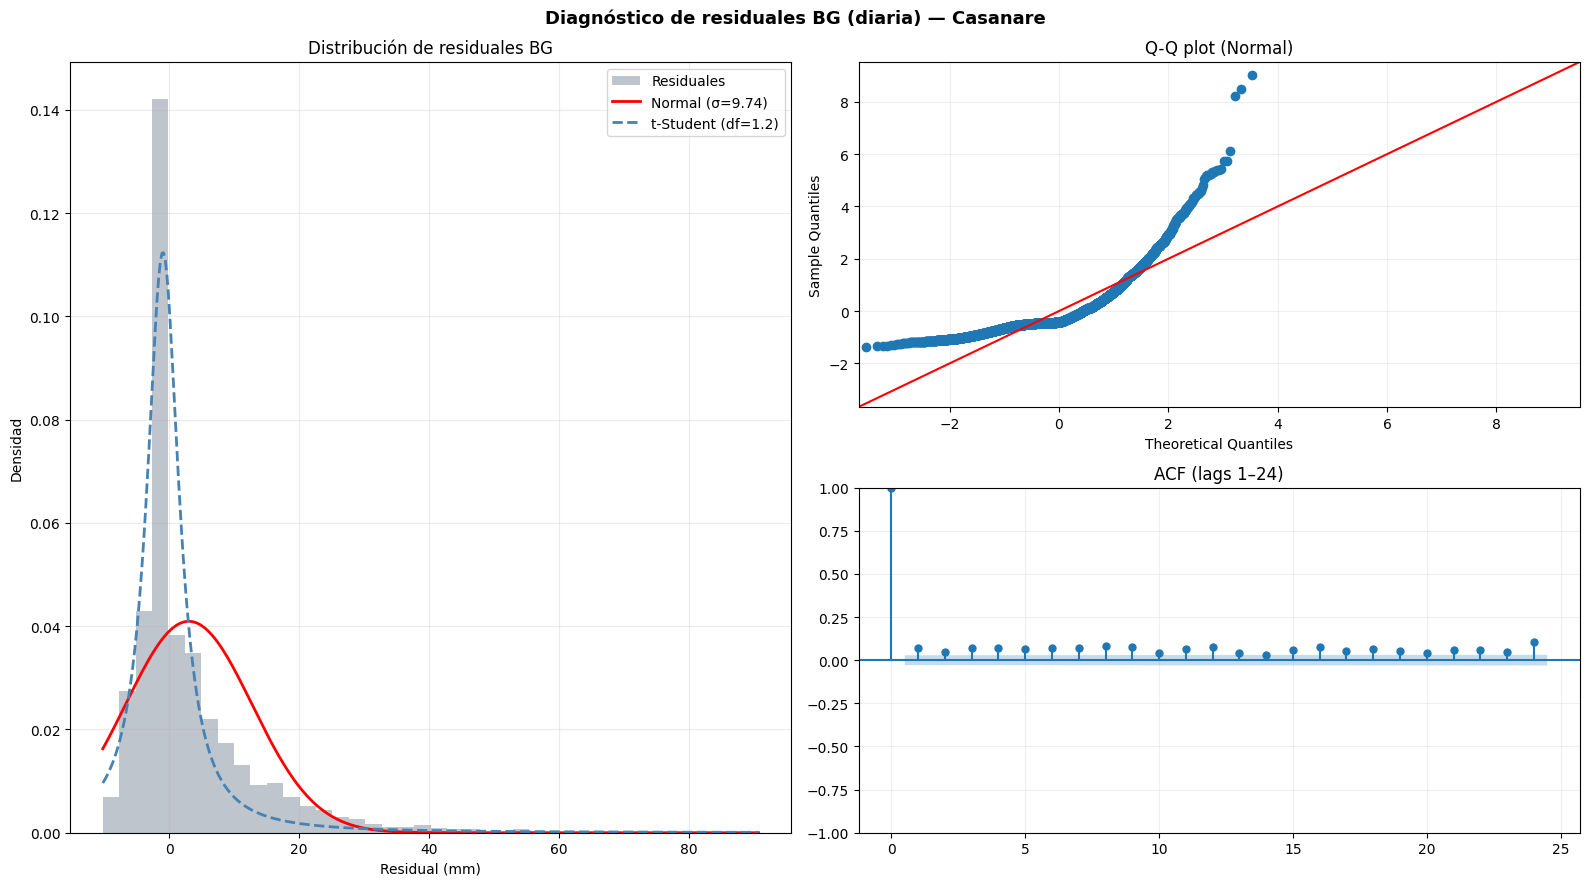

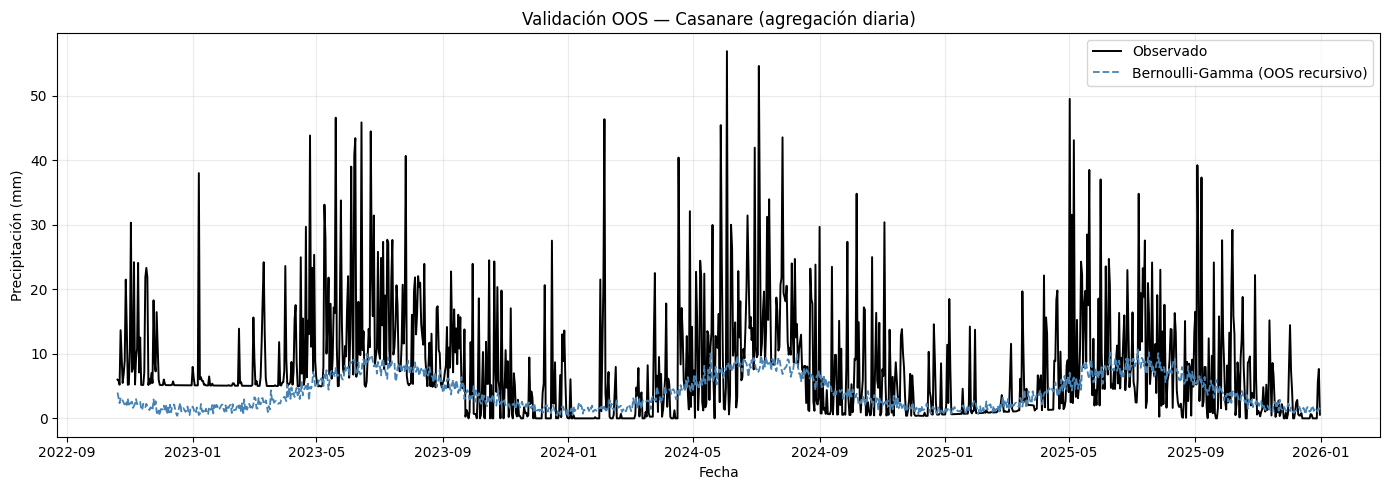


  BERNOULLI-GAMMA | TOLIMA | umbral=15 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0569
[2] Gamma (intensidad): scale (φ) = 0.0954

   [Logit] coeficientes:
               coef  std_err        z   p>|z|
const       -2.7663   0.0751 -36.8144  0.0000
sin_year     0.1847   0.0682   2.7099  0.0067
cos_year    -0.0419   0.0716  -0.5854  0.5583
lag1_precip  0.0365   0.0055   6.5848  0.0000
lag2_precip  0.0539   0.0053  10.1690  0.0000

   [Gamma] coeficientes:
               coef  std_err         z   p>|z|
const        3.1371   0.0242  129.7323  0.0000
sin_year     0.0174   0.0186    0.9345  0.3500
cos_year    -0.0313   0.0230   -1.3608  0.1736
lag1_precip -0.0024   0.0018   -1.3232  0.1858
lag2_precip  0.0004   0.0014    0.2792  0.7801

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=9939.92,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=3.1365,  σ=7.0874      AIC=31567.9
   t-Student : df=1.15, loc=-0.2331, scale=2.1558  AIC=29455.7
   → Selección A

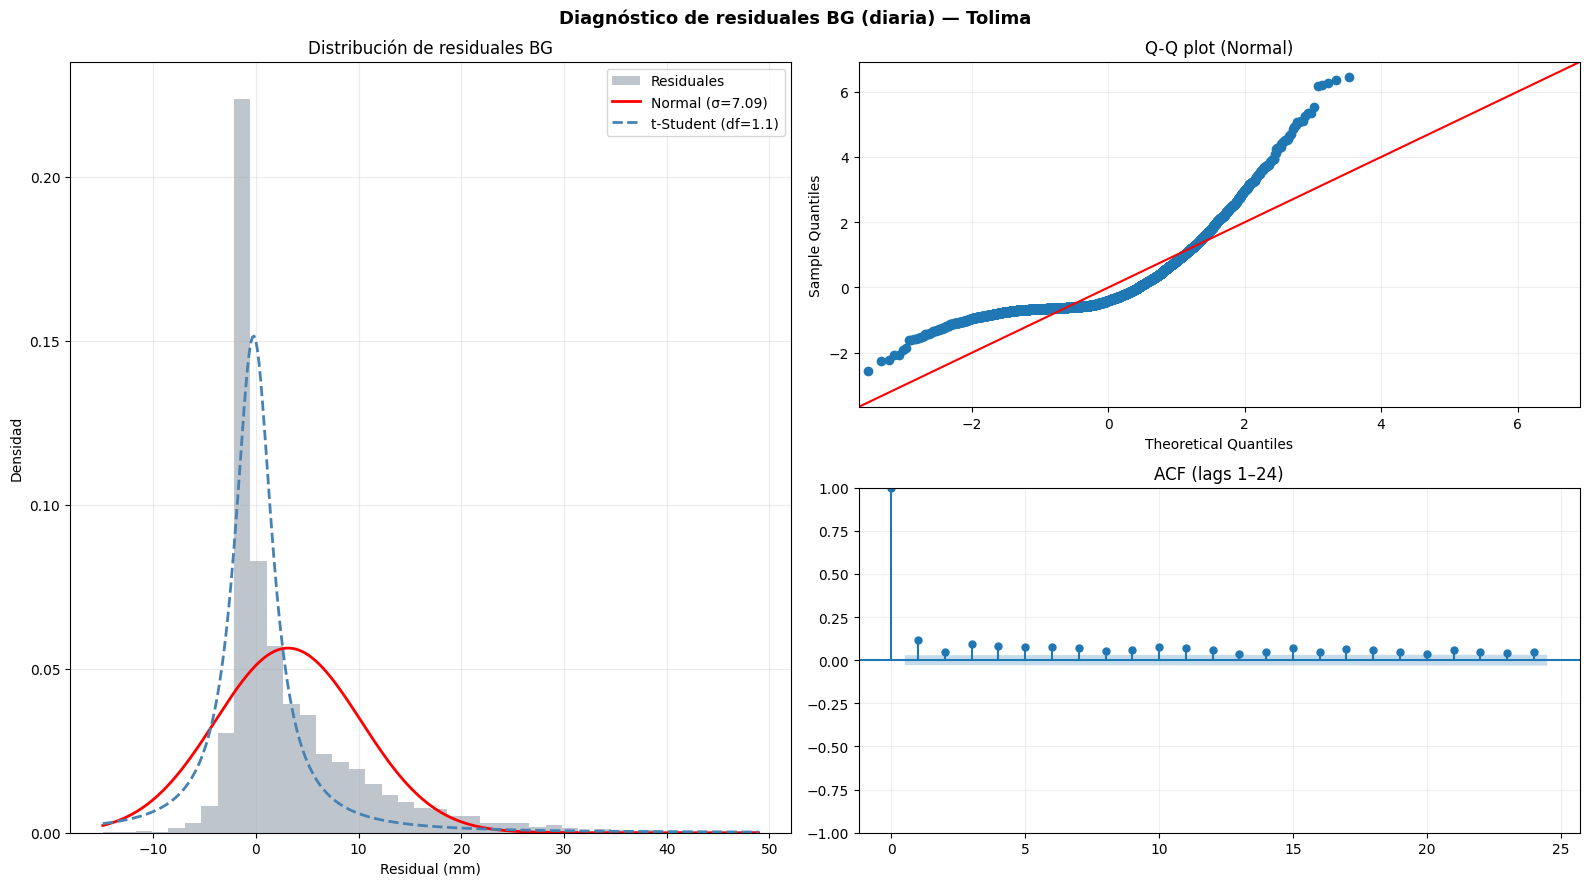

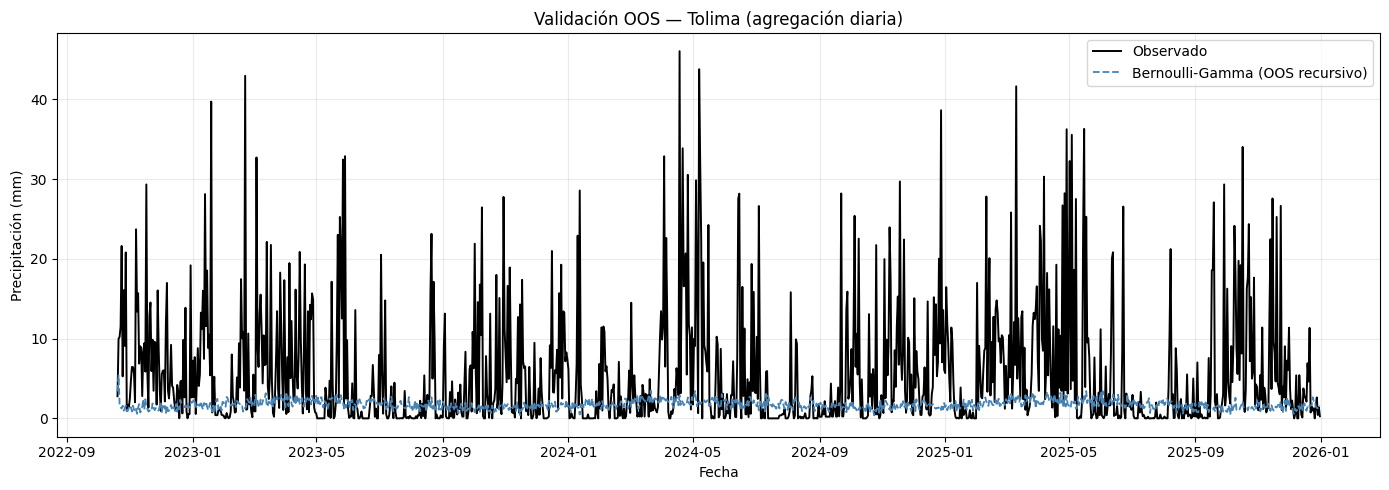


Sensibilidad al umbral:
             MAE                                      RMSE                \
threshold     1      3      5      7      10     15     1      3      5    
dpto                                                                       
Casanare   5.423  5.418  5.345  5.351  5.341  5.453  7.940  8.009  8.033   
Tolima     5.398  5.191  5.102  4.975  4.939  5.011  7.496  7.532  7.661   

                                
threshold     7      10     15  
dpto                            
Casanare   8.169  8.341  8.839  
Tolima     7.775  8.052  8.498  


In [12]:
filas = []
for thr in [1, 3, 5, 7, 10, 15]:
    for dpto, df_dpto in [('Casanare', df_Casanare), ('Tolima', df_Tolima)]:
        r = ajustar_bernoulli_gamma(df_dpto, dpto, frecuencia='diaria', threshold=thr)
        filas.append({'dpto': dpto, 'threshold': thr,
                      'RMSE': r['parametros_mc']['rmse_oos'],
                      'MAE':  r['parametros_mc']['mae_oos']})
        plt.close('all')   # silenciar plots de la sensibilidad para no saturar la salida

sens = pd.DataFrame(filas)
print("\nSensibilidad al umbral:")
print(sens.pivot_table(index='dpto', columns='threshold', values=['RMSE', 'MAE']).round(3))

## Exportación de parámetros

Se exportan a `data/processed/params_bg.json` los parámetros del Logit, la Gamma y los residuales para uso en el notebook 06 (simulación Monte Carlo).


  BERNOULLI-GAMMA | CASANARE | umbral=3 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1708
[2] Gamma (intensidad): scale (φ) = 0.6051

   [Logit] coeficientes:
               coef  std_err        z  p>|z|
const       -0.3524   0.0479  -7.3522    0.0
sin_year    -0.2755   0.0450  -6.1220    0.0
cos_year    -1.1139   0.0534 -20.8533    0.0
lag1_precip  0.0384   0.0039   9.7720    0.0
lag2_precip  0.0155   0.0035   4.4004    0.0

   [Gamma] coeficientes:
               coef  std_err        z   p>|z|
const        2.5798   0.0263  98.2250  0.0000
sin_year     0.0053   0.0222   0.2387  0.8113
cos_year    -0.2123   0.0272  -7.8187  0.0000
lag1_precip  0.0000   0.0015   0.0233  0.9814
lag2_precip -0.0008   0.0015  -0.5608  0.5749

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19338.07,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.2712,  σ=9.6056      AIC=34409.3
   t-Student : df=1.51, loc=-2.2899, scale=3.7032  AIC=32276.9
   → Selección AIC: t-Stud

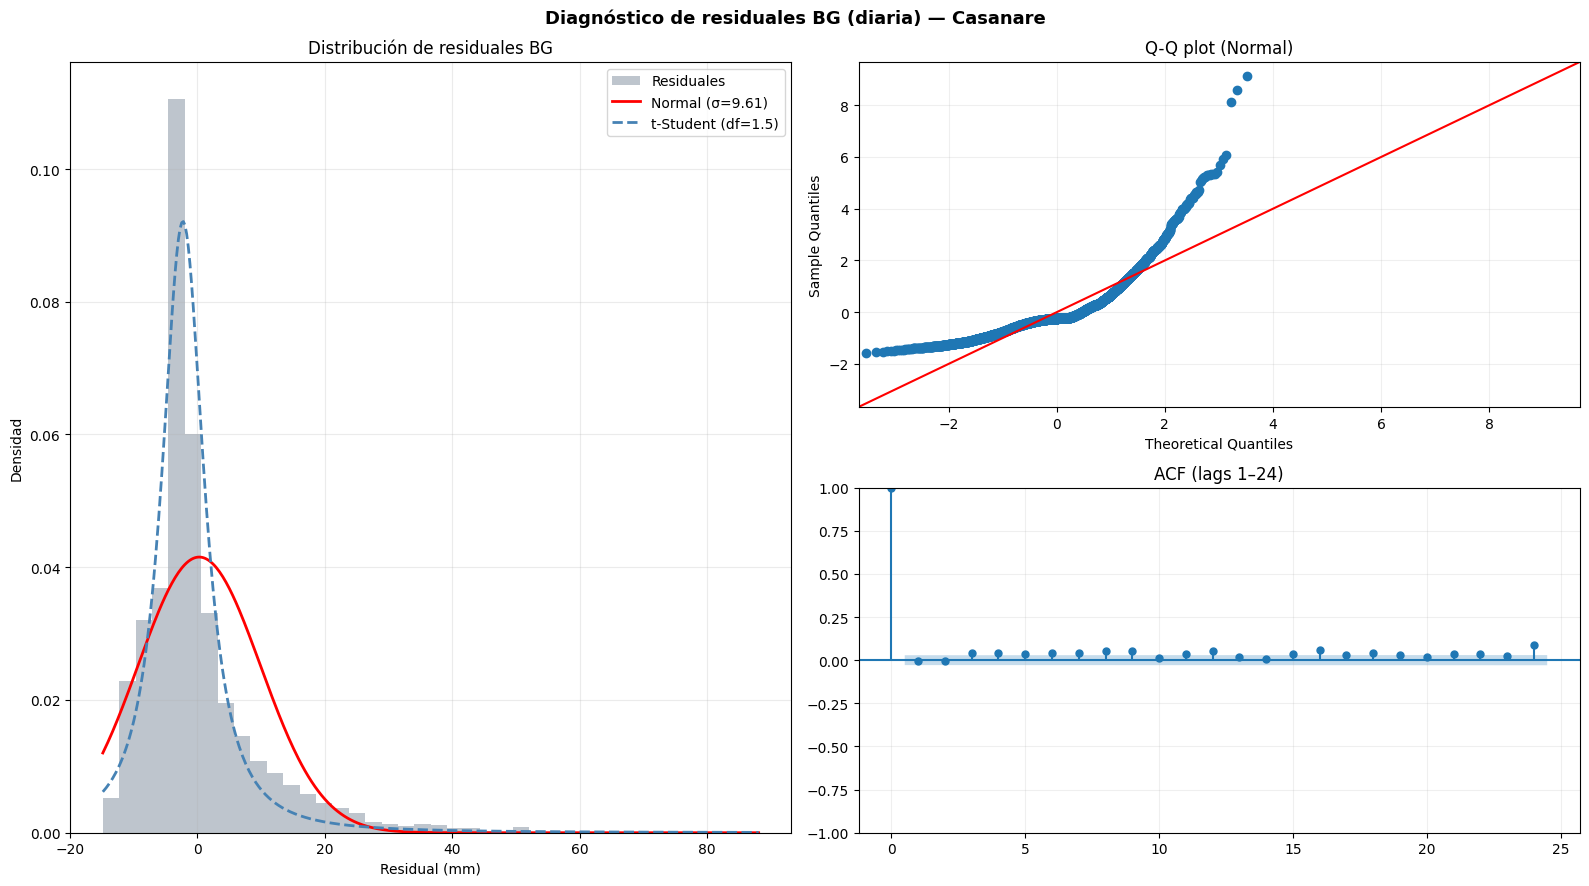

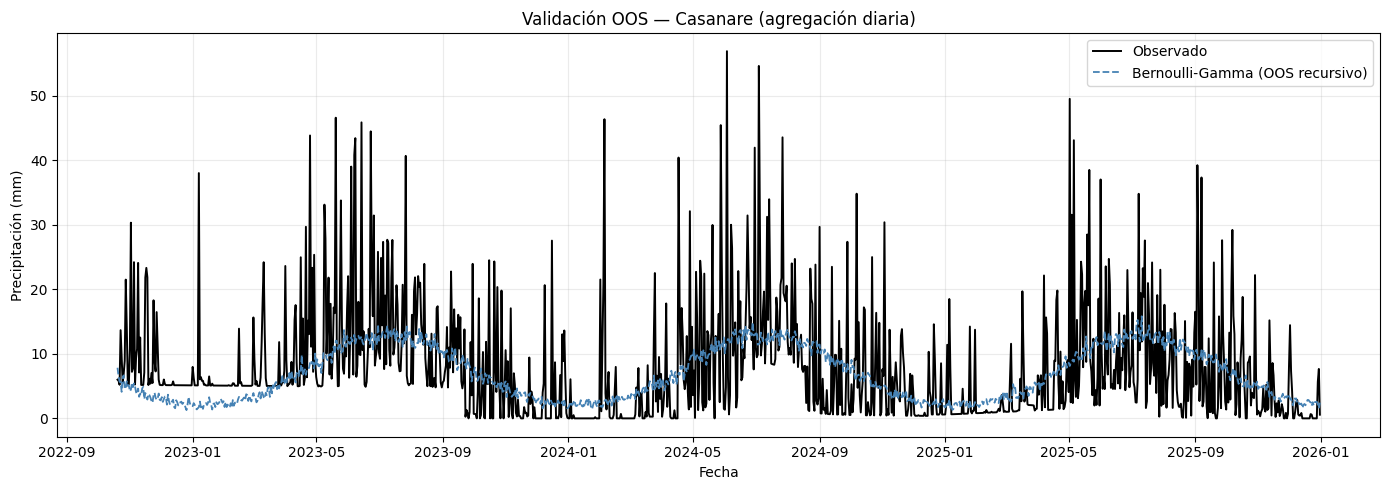


  BERNOULLI-GAMMA | TOLIMA | umbral=5 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0821
[2] Gamma (intensidad): scale (φ) = 0.3384

   [Logit] coeficientes:
               coef  std_err        z   p>|z|
const       -1.2193   0.0473 -25.8036  0.0000
sin_year     0.1047   0.0454   2.3070  0.0211
cos_year     0.3651   0.0463   7.8835  0.0000
lag1_precip  0.0651   0.0047  13.9591  0.0000
lag2_precip  0.0422   0.0044   9.5422  0.0000

   [Gamma] coeficientes:
               coef  std_err         z   p>|z|
const        2.5032   0.0235  106.3649  0.0000
sin_year     0.0231   0.0192    1.2023  0.2292
cos_year    -0.1094   0.0225   -4.8551  0.0000
lag1_precip -0.0002   0.0018   -0.0971  0.9227
lag2_precip  0.0090   0.0018    5.0599  0.0000

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10819.51,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.8813,  σ=6.9725      AIC=31415.1
   t-Student : df=1.17, loc=-1.9548, scale=2.1318  AIC=29162.3
   → Selección A

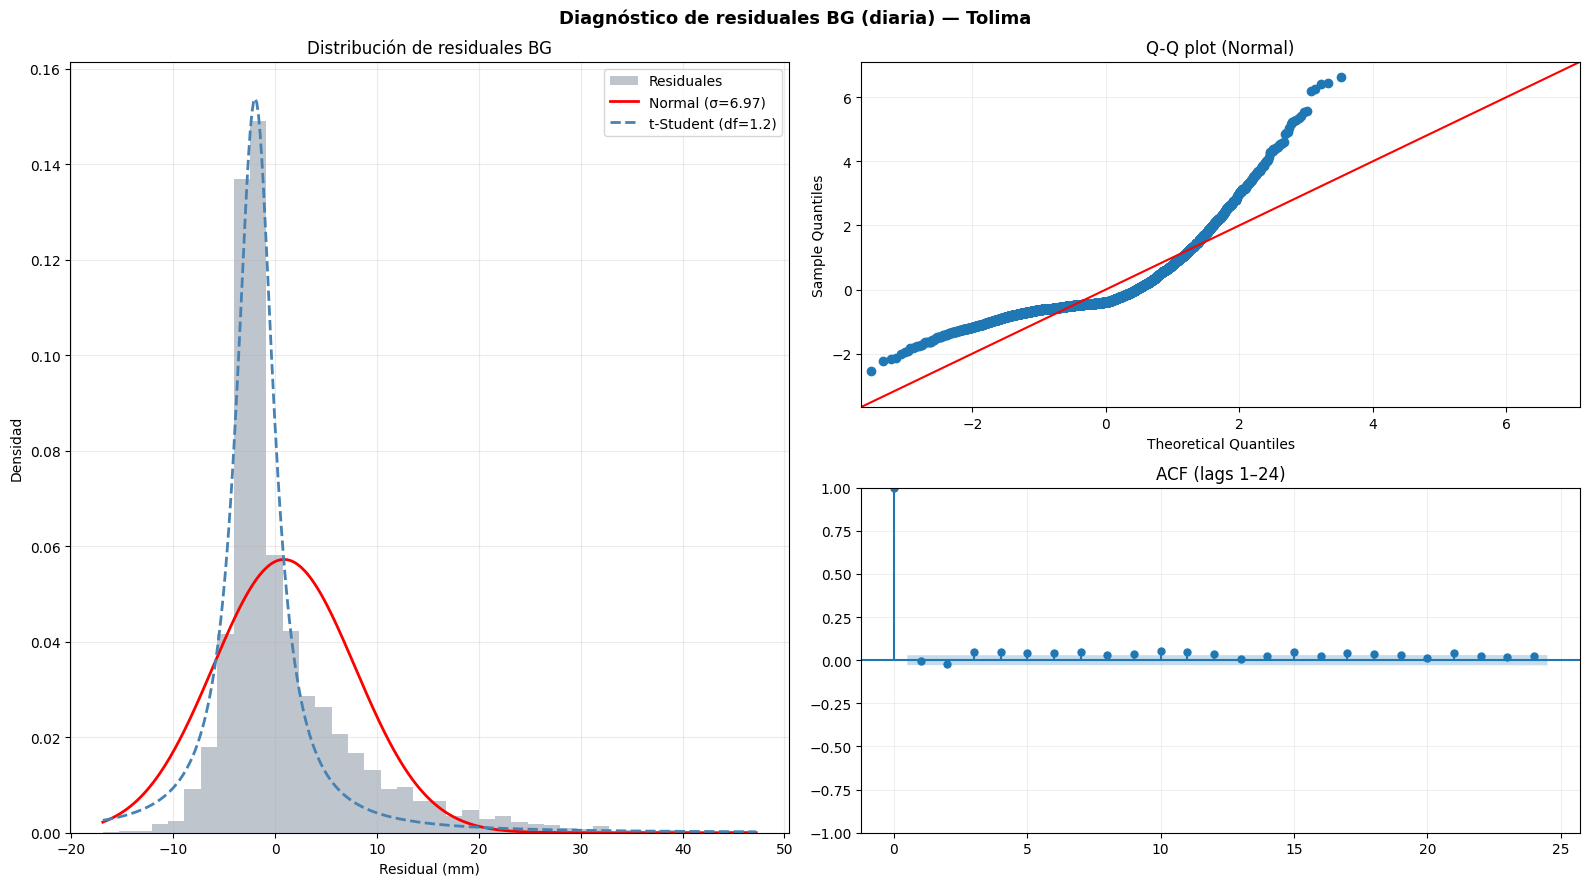

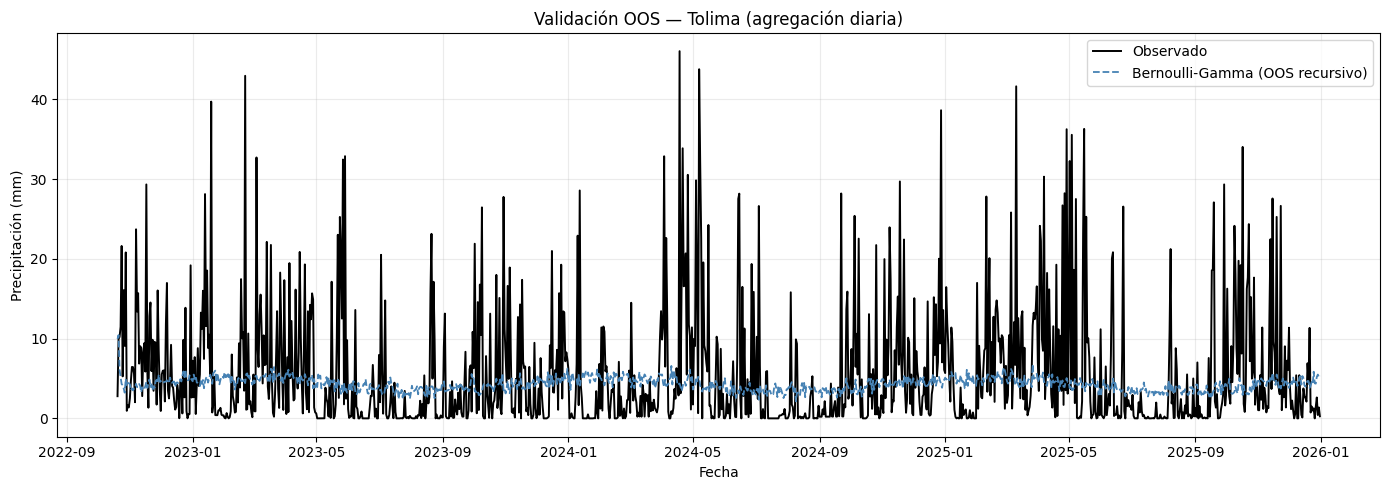

In [13]:
res_casanare = ajustar_bernoulli_gamma(df_Casanare, 'Casanare', frecuencia='diaria', threshold=3)
res_tolima   = ajustar_bernoulli_gamma(df_Tolima,   'Tolima',   frecuencia='diaria', threshold=5)

In [14]:
params_bg = {
    'Tolima':   res_tolima['parametros_mc'],
    'Casanare': res_casanare['parametros_mc'],
}

out_path = OUT_DIR / 'params_bg.json'
with open(out_path, 'w') as f:
    json.dump(params_bg, f, indent=2, ensure_ascii=False)

print(f"Parámetros BG exportados a: {out_path}")
print(json.dumps({k: {kk: vv for kk, vv in v.items() if kk != 'logit_coefs' and kk != 'gamma_coefs'}
                  for k, v in params_bg.items()}, indent=2, ensure_ascii=False))

Parámetros BG exportados a: ..\data\processed\params_bg.json
{
  "Tolima": {
    "threshold_lluvia": 5,
    "gamma_scale": 0.3384277160718632,
    "residuales_normal": {
      "mu": 0.8812726814049326,
      "sigma": 6.972484892065777
    },
    "residuales_t": {
      "df": 1.172357027567542,
      "loc": -1.954828831780437,
      "scale": 2.1318225052052027
    },
    "residuales_mejor": "t",
    "rmse_oos": 7.661122346360087,
    "mae_oos": 5.101607363066489,
    "jb_p": 0.0,
    "oos_recursivo": true,
    "oos_n_sims": 200
  },
  "Casanare": {
    "threshold_lluvia": 3,
    "gamma_scale": 0.6051130314041883,
    "residuales_normal": {
      "mu": 0.271203729866437,
      "sigma": 9.605563745781655
    },
    "residuales_t": {
      "df": 1.5118571255935846,
      "loc": -2.2898967713178067,
      "scale": 3.703229397960392
    },
    "residuales_mejor": "t",
    "rmse_oos": 8.009499782554647,
    "mae_oos": 5.417564013312395,
    "jb_p": 0.0,
    "oos_recursivo": true,
    "oos_n_s